# Attack Graph Papers — Comparative Analysis for GAP Construction

**Author:** Marc Labouchardiere
**Date:** April 2026
**Purpose:** Side-by-side replication and comparison of four papers on MITRE ATT&CK technique dependency / sequencing, used as candidate edge sources for the **Generalised Attack Profile (GAP)** — the single global technique-dependency DAG defined in `2026-04-08_MTDSim_AttackGraphDesignSchema.md`.

## What this notebook does

The GAP design schema (v0.2) describes a single global graph where nodes are ATT&CK techniques (arranged by tactic layer) and edges are dependencies between techniques. The hard problem is **deriving those edges** — MITRE ATT&CK records only set membership (campaign -> technique), not ordering. This notebook explores four published approaches and lets me evaluate each one as a candidate edge source, side by side, on the same data.

| § | Paper | Edge source | Output |
|---|-------|-------------|--------|
| 2 | Rahman et al. (2022) — *Investigating co-occurrences of MITRE ATT&CK Techniques* | Statistical association rules over campaign/group/software technique sets | Co-occurrence rule edges |
| 3 | Choi et al. (2021) — *Probabilistic Attack Sequence Generation Based on MITRE ATT&CK* | HMM over canonical tactic ordering | Tactic-level transition matrix |
| 4 | Zhang et al. (2025) — *DeepOP* (simplified) | Ontology-style precondition extraction from technique descriptions | Documentation-backed edges |
| 5 | MITRE CTID — *Attack Flow* corpus (AttacKG+ style import) | Manually curated structured attack flows | High-fidelity flow edges |

Section 6 unifies the four edge sets and computes overlap. Section 7 overlays the unified set onto the GAP node set to find which techniques still need manual annotation.

## How to read the outputs

Each section ends with a **Key output for the GAP** note explaining what the section contributes back to the design schema. The integration in §6 is the load-bearing result: it tells me which edges have multi-source support (high confidence), which are unique to one source (need verification), and how much of the graph is already covered before any manual work.


---

## Section 1 — Setup & Data Ingestion

Loads the Enterprise ATT&CK STIX 2.1 bundle and extracts the four data layers used by every later section: techniques, campaigns, groups, and the `uses` relationships that bind them together.

The bundle is loaded from a local copy at [enterprise-attack.json](enterprise-attack.json) if present (the same file used by [2026-04-07_MTDSim_MITRESTIXExploration.ipynb](2026-04-07_MTDSim_MITRESTIXExploration.ipynb)). Otherwise it is fetched fresh from the MITRE CTI repo.


In [1]:
# One-time install. Comment out after first run.
# %pip install -q mitreattack-python networkx pyvis matplotlib pandas seaborn mlxtend requests


In [2]:
import json
import os
import re
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Canonical ATT&CK Enterprise tactic ordering (matches GAP schema layers 0-13).
CANONICAL_TACTICS = [
    "reconnaissance",
    "resource-development",
    "initial-access",
    "execution",
    "persistence",
    "privilege-escalation",
    "defense-evasion",
    "credential-access",
    "discovery",
    "lateral-movement",
    "collection",
    "command-and-control",
    "exfiltration",
    "impact",
]
TACTIC_LAYER = {t: i for i, t in enumerate(CANONICAL_TACTICS)}
TACTIC_DISPLAY = {t: t.replace("-", " ").title() for t in CANONICAL_TACTICS}

# 14-colour categorical palette for tactic-layer encoding (used in every section).
TACTIC_COLORS = dict(zip(CANONICAL_TACTICS, sns.color_palette("tab20", n_colors=14).as_hex()))

NOTEBOOK_DIR = Path.cwd()
print(f"Notebook dir: {NOTEBOOK_DIR}")


Notebook dir: /home/marc/GitHub/MTDSim/notebooks


In [3]:
# Load the Enterprise ATT&CK STIX 2.1 bundle.
STIX_LOCAL = NOTEBOOK_DIR / "enterprise-attack.json"
STIX_URL = "https://raw.githubusercontent.com/mitre/cti/master/enterprise-attack/enterprise-attack.json"

if STIX_LOCAL.exists():
    print(f"Using local STIX bundle: {STIX_LOCAL} ({STIX_LOCAL.stat().st_size / 1e6:.1f} MB)")
    with open(STIX_LOCAL) as f:
        bundle = json.load(f)
else:
    import requests
    print(f"Downloading STIX bundle from {STIX_URL} ...")
    resp = requests.get(STIX_URL, timeout=60)
    resp.raise_for_status()
    bundle = resp.json()
    with open(STIX_LOCAL, "w") as f:
        json.dump(bundle, f)
    print(f"Saved local copy to {STIX_LOCAL}")

objects = bundle["objects"]
print(f"STIX objects loaded: {len(objects):,}")


Using local STIX bundle: /home/marc/GitHub/MTDSim/notebooks/enterprise-attack.json (45.1 MB)
STIX objects loaded: 24,771


In [4]:
# Build flat extraction tables: techniques, campaigns, groups, software, relationships.
def attack_id(obj):
    """Return the external ATT&CK ID (T1059, G0016, C0015, S0002...) or None."""
    for ref in obj.get("external_references", []) or []:
        if ref.get("source_name") == "mitre-attack":
            return ref.get("external_id")
    return None


def parent_technique_id(tid):
    """Collapse sub-technique IDs (T1059.001 -> T1059)."""
    return tid.split(".")[0] if tid and "." in tid else tid


techniques = {}        # parent_id -> dict of fields
sub_to_parent = {}     # full id (incl sub) -> parent id
techniques_by_stix = {}  # stix object id -> parent attack id
campaigns = {}         # campaign attack id -> dict
groups = {}            # group attack id -> dict
software = {}          # software attack id -> dict
relationships = []     # raw relationship records

for obj in objects:
    if obj.get("revoked") or obj.get("x_mitre_deprecated"):
        continue
    otype = obj.get("type")

    if otype == "attack-pattern":
        tid_full = attack_id(obj)
        if not tid_full:
            continue
        parent = parent_technique_id(tid_full)
        sub_to_parent[tid_full] = parent
        techniques_by_stix[obj["id"]] = parent

        rec = techniques.setdefault(parent, {
            "technique_id": parent,
            "name": None,
            "description": "",
            "tactics": set(),
            "platforms": set(),
            "sub_technique_ids": set(),
            "x_mitre_prerequisites": [],
        })
        # Parent record gets the parent's own name; sub-techniques contribute tactics/desc.
        if tid_full == parent:
            rec["name"] = obj.get("name")
            rec["description"] = obj.get("description", "") or ""
            rec["x_mitre_prerequisites"] = obj.get("x_mitre_prerequisites", []) or []
        else:
            rec["sub_technique_ids"].add(tid_full)
            # Use sub-technique description as a fallback if parent had none yet.
            if not rec["description"]:
                rec["description"] = obj.get("description", "") or ""

        for kc in obj.get("kill_chain_phases", []) or []:
            if kc.get("kill_chain_name") == "mitre-attack":
                rec["tactics"].add(kc.get("phase_name"))
        for plat in obj.get("x_mitre_platforms", []) or []:
            rec["platforms"].add(plat)

    elif otype == "campaign":
        cid = attack_id(obj)
        if cid:
            campaigns[cid] = {
                "campaign_id": cid,
                "stix_id": obj["id"],
                "name": obj.get("name"),
                "description": obj.get("description", "") or "",
                "first_seen": obj.get("first_seen"),
                "last_seen": obj.get("last_seen"),
            }

    elif otype == "intrusion-set":
        gid = attack_id(obj)
        if gid:
            groups[gid] = {
                "group_id": gid,
                "stix_id": obj["id"],
                "name": obj.get("name"),
            }

    elif otype in ("malware", "tool"):
        sid = attack_id(obj)
        if sid:
            software[sid] = {
                "software_id": sid,
                "stix_id": obj["id"],
                "name": obj.get("name"),
                "type": otype,
            }

    elif otype == "relationship":
        relationships.append(obj)

# Resolve stix_id -> attack_id for campaigns, groups, and software.
stix_to_attack = {}
for v in campaigns.values():
    stix_to_attack[v["stix_id"]] = v["campaign_id"]
for v in groups.values():
    stix_to_attack[v["stix_id"]] = v["group_id"]
for v in software.values():
    stix_to_attack[v["stix_id"]] = v["software_id"]

print(f"Techniques (collapsed to parent): {len(techniques):,}")
print(f"Campaigns:                       {len(campaigns):,}")
print(f"Groups:                          {len(groups):,}")
print(f"Software (malware + tools):      {len(software):,}")
print(f"Relationships (all types):       {len(relationships):,}")


Techniques (collapsed to parent): 216
Campaigns:                       52
Groups:                          172
Software (malware + tools):      784
Relationships (all types):       20,048


In [5]:
# Walk relationships and build: actor -> set of techniques used.
# Resolve campaign/group/software <-> technique edges, including indirect group->software->technique chains.
campaign_techniques = defaultdict(set)
group_techniques = defaultdict(set)
software_techniques = defaultdict(set)

# Direct uses edges
for rel in relationships:
    if rel.get("relationship_type") != "uses":
        continue
    src = rel.get("source_ref", "")
    tgt = rel.get("target_ref", "")
    if tgt not in techniques_by_stix:
        continue
    parent_tid = techniques_by_stix[tgt]

    if src.startswith("campaign--"):
        cid = stix_to_attack.get(src)
        if cid:
            campaign_techniques[cid].add(parent_tid)
    elif src.startswith("intrusion-set--"):
        gid = stix_to_attack.get(src)
        if gid:
            group_techniques[gid].add(parent_tid)
    elif src.startswith(("malware--", "tool--")):
        sid = stix_to_attack.get(src)
        if sid:
            software_techniques[sid].add(parent_tid)

# Annotate technique nodes with provenance counts.
technique_to_campaigns = defaultdict(set)
technique_to_groups = defaultdict(set)
for cid, tset in campaign_techniques.items():
    for t in tset:
        technique_to_campaigns[t].add(cid)
for gid, tset in group_techniques.items():
    for t in tset:
        technique_to_groups[t].add(gid)

for tid, rec in techniques.items():
    rec["campaign_count"] = len(technique_to_campaigns.get(tid, set()))
    rec["campaign_ids"]   = sorted(technique_to_campaigns.get(tid, set()))
    rec["group_ids"]      = sorted(technique_to_groups.get(tid, set()))
    # Convert sets to sorted lists for stable downstream use.
    rec["tactics"] = sorted(rec["tactics"], key=lambda t: TACTIC_LAYER.get(t, 99))
    rec["platforms"] = sorted(rec["platforms"])
    rec["sub_technique_ids"] = sorted(rec["sub_technique_ids"])
    rec["primary_tactic"] = rec["tactics"][0] if rec["tactics"] else None
    rec["tactic_layer"] = TACTIC_LAYER.get(rec["primary_tactic"], -1)

# Summary stats
avg_techs_per_campaign = (
    sum(len(v) for v in campaign_techniques.values()) / max(len(campaign_techniques), 1)
)
avg_techs_per_group = (
    sum(len(v) for v in group_techniques.values()) / max(len(group_techniques), 1)
)
print(f"Techniques:                    {len(techniques):,}")
print(f"Campaigns w/ tech links:       {len(campaign_techniques):,}")
print(f"Groups w/ tech links:          {len(group_techniques):,}")
print(f"Software w/ tech links:        {len(software_techniques):,}")
print(f"Avg techniques per campaign:   {avg_techs_per_campaign:.1f}")
print(f"Avg techniques per group:      {avg_techs_per_group:.1f}")
print()
print("Top 10 techniques by campaign_count:")
top = sorted(techniques.values(), key=lambda r: -r["campaign_count"])[:10]
for r in top:
    print(f"  {r['technique_id']:<8}  campaigns={r['campaign_count']:>3}  {r['name']}")


Techniques:                    216
Campaigns w/ tech links:       51
Groups w/ tech links:          168
Software w/ tech links:        784
Avg techniques per campaign:   17.0
Avg techniques per group:      20.8

Top 10 techniques by campaign_count:
  T1059     campaigns= 38  Command and Scripting Interpreter
  T1588     campaigns= 29  Obtain Capabilities
  T1105     campaigns= 28  Ingress Tool Transfer
  T1583     campaigns= 25  Acquire Infrastructure
  T1027     campaigns= 24  Obfuscated Files or Information
  T1071     campaigns= 24  Application Layer Protocol
  T1036     campaigns= 23  Masquerading
  T1190     campaigns= 19  Exploit Public-Facing Application
  T1003     campaigns= 16  OS Credential Dumping
  T1584     campaigns= 16  Compromise Infrastructure


---

## Section 2 — Rahman et al. (2022): Co-occurrence Analysis

> Rahman, M.R. et al. *Investigating co-occurrences of MITRE ATT&CK Techniques.*

**Method.** Treat each adversary actor (group + software) as a "transaction" and the techniques they use as "items". Apply association rule mining (FP-Growth) to find pairs of techniques that frequently co-occur, then keep rules where the consequent is reliably predicted by the antecedent.

**What this gives the GAP.** Each high-confidence rule `T_a -> T_b` is a candidate dependency edge: "actors that use T_a tend to also use T_b". Co-occurrence is *not* causation — it does not prove ordering — but it surfaces empirically tight technique pairings that are strong candidates for manual review. Edges that cross from a lower tactic layer to a higher one are especially interesting.


In [6]:
# Build the actor x technique 0/1 usage matrix.
# Rows = groups + software (Rahman uses both as "transactions"); columns = parent techniques.
from mlxtend.frequent_patterns import fpgrowth, association_rules

actor_techniques = {}
for gid, tset in group_techniques.items():
    actor_techniques[f"G:{gid}"] = tset
for sid, tset in software_techniques.items():
    actor_techniques[f"S:{sid}"] = tset

# Drop very small actors (< 3 techniques) — Rahman filters these as noise.
actor_techniques = {k: v for k, v in actor_techniques.items() if len(v) >= 3}

all_techs = sorted({t for tset in actor_techniques.values() for t in tset})
matrix = pd.DataFrame(
    [[t in actor_techniques[k] for t in all_techs] for k in actor_techniques],
    index=list(actor_techniques.keys()),
    columns=all_techs,
).astype(bool)

print(f"Usage matrix: {matrix.shape[0]} actors x {matrix.shape[1]} techniques")
print(f"Density: {matrix.values.mean():.3%}")
matrix.head()


Usage matrix: 877 actors x 207 techniques
Density: 7.144%


,T1001,T1003,T1005,T1006,T1007,T1008,T1010,T1011,T1012,T1014,...,T1665,T1667,T1669,T1673,T1674,T1675,T1678,T1679,T1680,T1681
G:G0119,False,True,False,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
G:G1014,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
G:G1051,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
G:G0102,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
G:G0046,False,False,True,False,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [7]:
# Run FP-Growth to find frequent itemsets, then derive association rules.
MIN_SUPPORT = 0.10
MIN_CONFIDENCE = 0.60

frequent = fpgrowth(matrix, min_support=MIN_SUPPORT, use_colnames=True, max_len=4)
print(f"Frequent itemsets at support>={MIN_SUPPORT}: {len(frequent):,}")

rules = association_rules(frequent, metric="confidence", min_threshold=MIN_CONFIDENCE)
rules = rules.sort_values("confidence", ascending=False).reset_index(drop=True)
print(f"Rules at confidence>={MIN_CONFIDENCE}: {len(rules):,}")

# Split into "simple" (1->1) and "compound" (multi-antecedent or multi-consequent).
def is_simple(row):
    return len(row["antecedents"]) == 1 and len(row["consequents"]) == 1

simple_rules = rules[rules.apply(is_simple, axis=1)].reset_index(drop=True)
compound_rules = rules[~rules.apply(is_simple, axis=1)].reset_index(drop=True)
print(f"  Simple   (1->1): {len(simple_rules):,}")
print(f"  Compound       : {len(compound_rules):,}")


Frequent itemsets at support>=0.1: 729
Rules at confidence>=0.6: 1,324
  Simple   (1->1): 128
  Compound       : 1,196


In [8]:
# Decorate rules with technique names + tactic transition labels.
def name_of(tid):
    return techniques.get(tid, {}).get("name", tid)


def tactic_of(tid):
    return techniques.get(tid, {}).get("primary_tactic")


def transition_label(a_tid, c_tid):
    a, c = tactic_of(a_tid), tactic_of(c_tid)
    if not a or not c:
        return "unknown"
    if a == c:
        return f"same-tactic ({TACTIC_DISPLAY[a]})"
    return f"{TACTIC_DISPLAY[a]} -> {TACTIC_DISPLAY[c]}"


rule_records = []
for _, row in simple_rules.iterrows():
    a_tid = next(iter(row["antecedents"]))
    c_tid = next(iter(row["consequents"]))
    rule_records.append({
        "antecedent_id": a_tid,
        "antecedent_name": name_of(a_tid),
        "consequent_id": c_tid,
        "consequent_name": name_of(c_tid),
        "support": row["support"],
        "confidence": row["confidence"],
        "lift": row["lift"],
        "transition": transition_label(a_tid, c_tid),
    })

rules_df = pd.DataFrame(rule_records)
print(f"Simple rule records: {len(rules_df):,}\n")
print("Top 15 simple rules by confidence:")
display_cols = ["antecedent_id", "antecedent_name", "consequent_id", "consequent_name",
                "support", "confidence", "lift", "transition"]
rules_df.head(15)[display_cols]


Simple rule records: 128

Top 15 simple rules by confidence:


,antecedent_id,antecedent_name,consequent_id,consequent_name,support,confidence,lift,transition
0,T1566,Phishing,T1204,User Execution,0.168757,0.907975,4.042104,Initial Access -> Execution
1,T1497,Virtualization/Sandbox Evasion,T1027,Obfuscated Files or Information,0.110604,0.843478,1.629362,same-tactic (Defense Evasion)
2,T1047,Windows Management Instrumentation,T1059,Command and Scripting Interpreter,0.122007,0.842520,1.326553,same-tactic (Execution)
3,T1566,Phishing,T1059,Command and Scripting Interpreter,0.155074,0.834356,1.313698,Initial Access -> Execution
4,T1218,System Binary Proxy Execution,T1059,Command and Scripting Interpreter,0.147092,0.826923,1.301996,Defense Evasion -> Execution
5,T1132,Data Encoding,T1059,Command and Scripting Interpreter,0.129989,0.826087,1.300679,Command And Control -> Execution
6,T1033,System Owner/User Discovery,T1082,System Information Discovery,0.210946,0.825893,1.857200,same-tactic (Discovery)
7,T1021,Remote Services,T1059,Command and Scripting Interpreter,0.104903,0.821429,1.293344,Lateral Movement -> Execution
8,T1053,Scheduled Task/Job,T1059,Command and Scripting Interpreter,0.173318,0.817204,1.286693,same-tactic (Execution)
9,T1562,Impair Defenses,T1059,Command and Scripting Interpreter,0.136830,0.816327,1.285311,Defense Evasion -> Execution


Drawing 64 edges with confidence >= median (0.688)


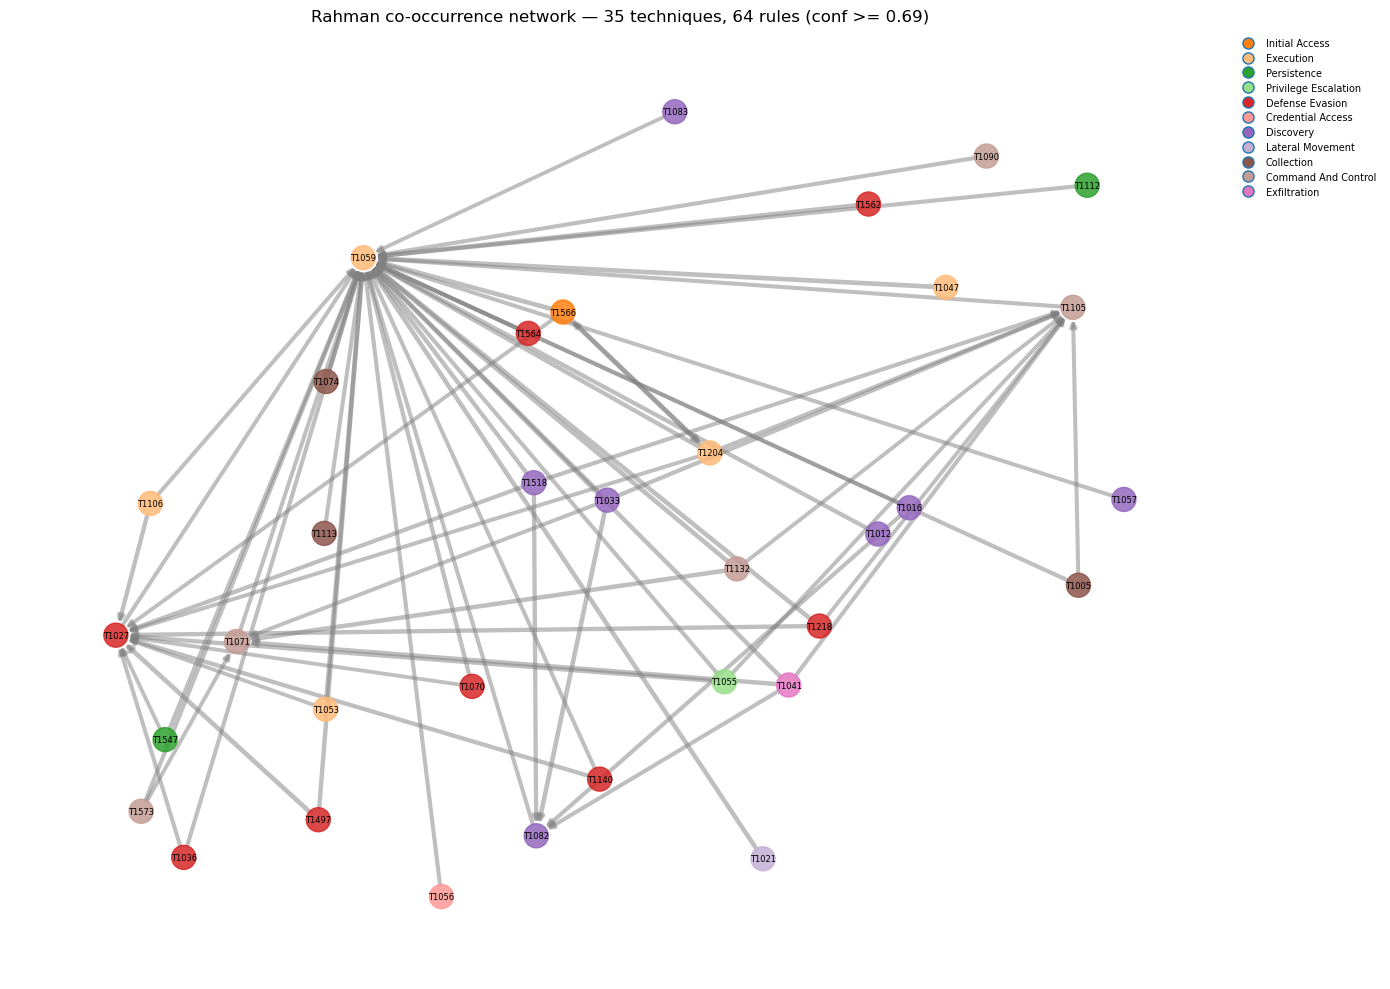

In [9]:
# Visualisation: co-occurrence network (NetworkX) — nodes = techniques, edges = rules.
median_conf = rules_df["confidence"].median() if len(rules_df) else MIN_CONFIDENCE
strong = rules_df[rules_df["confidence"] >= median_conf]
print(f"Drawing {len(strong)} edges with confidence >= median ({median_conf:.3f})")

G_cooc = nx.DiGraph()
for _, r in strong.iterrows():
    a, c = r["antecedent_id"], r["consequent_id"]
    G_cooc.add_node(a, tactic=tactic_of(a), name=name_of(a))
    G_cooc.add_node(c, tactic=tactic_of(c), name=name_of(c))
    G_cooc.add_edge(a, c, confidence=r["confidence"], lift=r["lift"])

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G_cooc, k=0.5, seed=42)
node_colors = [TACTIC_COLORS.get(G_cooc.nodes[n].get("tactic"), "#888") for n in G_cooc.nodes]
edge_widths = [G_cooc[u][v]["confidence"] * 4 for u, v in G_cooc.edges]
nx.draw_networkx_nodes(G_cooc, pos, node_size=300, node_color=node_colors, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_cooc, pos, width=edge_widths, edge_color="grey", alpha=0.5,
                       arrows=True, arrowsize=8, ax=ax)
nx.draw_networkx_labels(G_cooc, pos, font_size=6, ax=ax)

# Tactic legend
from matplotlib.lines import Line2D
legend_handles = [Line2D([0], [0], marker="o", linestyle="", markerfacecolor=c, markersize=8, label=TACTIC_DISPLAY[t])
                  for t, c in TACTIC_COLORS.items() if any(G_cooc.nodes[n].get("tactic") == t for n in G_cooc.nodes)]
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1, 1), fontsize=7, frameon=False)
ax.set_title(f"Rahman co-occurrence network — {len(G_cooc.nodes)} techniques, {len(G_cooc.edges)} rules (conf >= {median_conf:.2f})")
ax.axis("off")
plt.tight_layout()
plt.show()


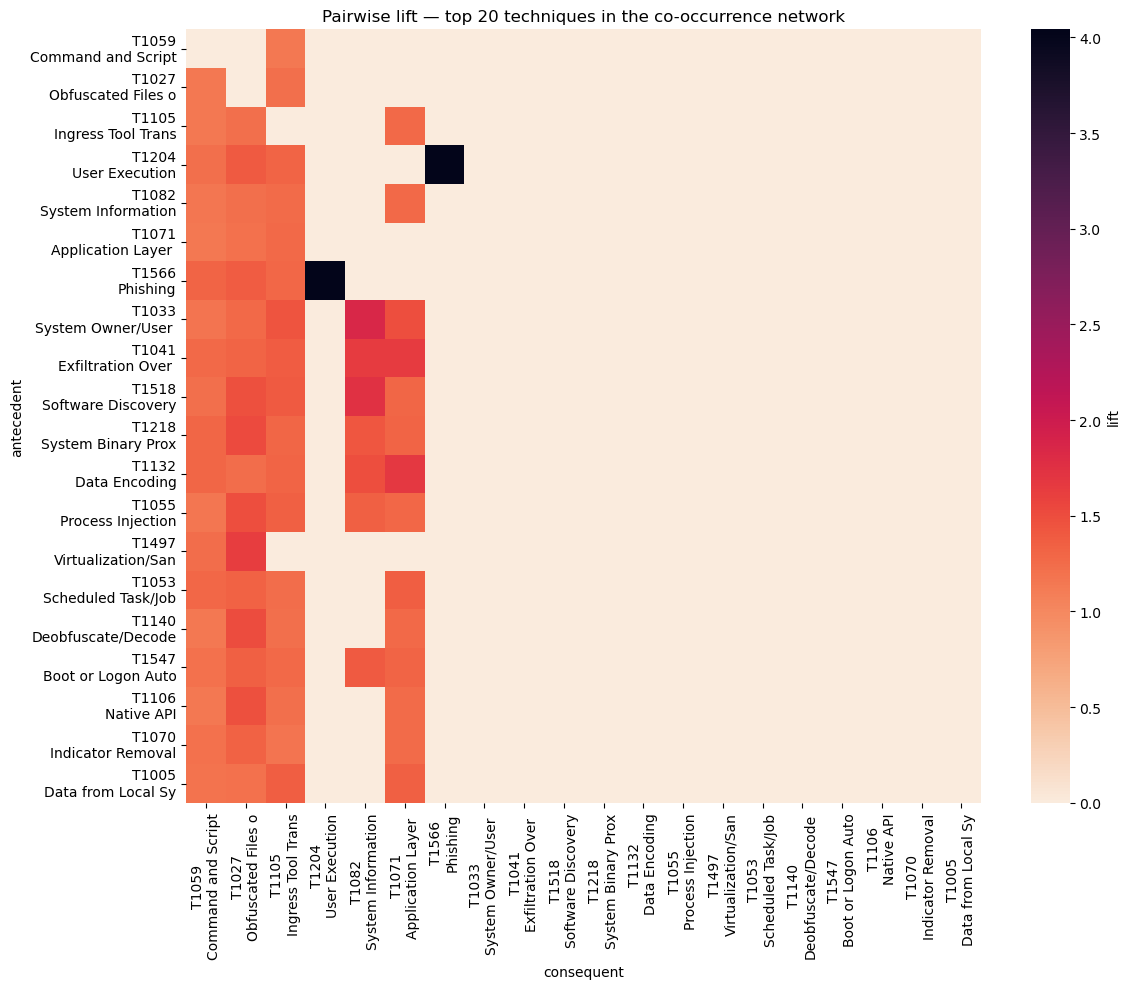

In [10]:
# Visualisation: lift heatmap of the top 20 most-connected techniques.
deg = dict(G_cooc.degree())
top20 = [n for n, _ in sorted(deg.items(), key=lambda kv: -kv[1])[:20]]

lift_matrix = pd.DataFrame(0.0, index=top20, columns=top20)
for _, r in rules_df.iterrows():
    a, c = r["antecedent_id"], r["consequent_id"]
    if a in top20 and c in top20:
        lift_matrix.loc[a, c] = r["lift"]

labels = [f"{tid}\n{name_of(tid)[:18]}" for tid in top20]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(lift_matrix, cmap="rocket_r", xticklabels=labels, yticklabels=labels,
            cbar_kws={"label": "lift"}, ax=ax)
ax.set_title("Pairwise lift — top 20 techniques in the co-occurrence network")
ax.set_xlabel("consequent")
ax.set_ylabel("antecedent")
plt.tight_layout()
plt.show()


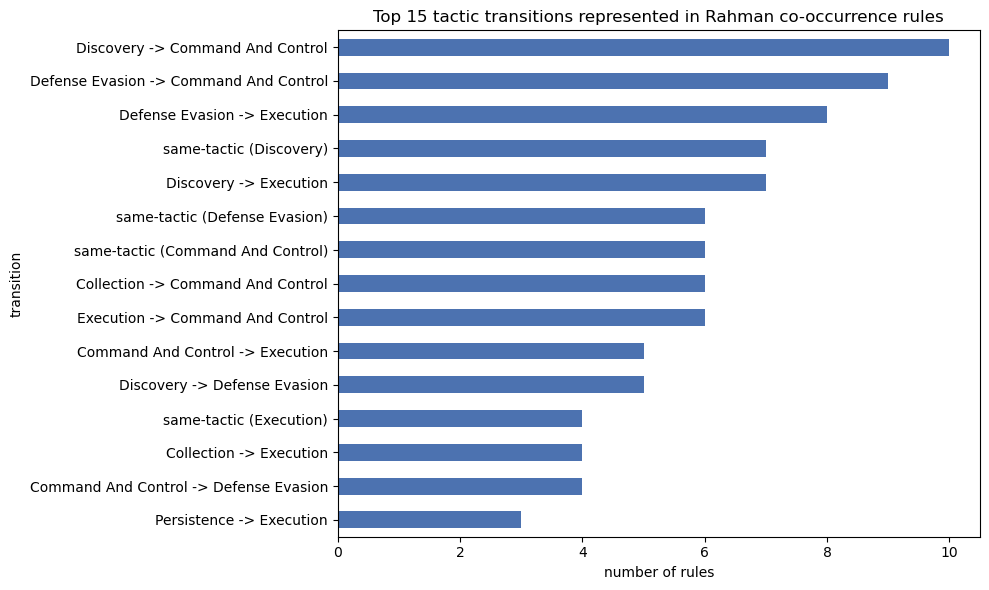


Saved 128 co-occurrence candidate edges for §6.


In [11]:
# Tactic-transition breakdown — how do co-occurrence rules sit relative to canonical tactic ordering?
trans_counts = rules_df["transition"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
trans_counts.plot.barh(ax=ax, color="#4c72b0")
ax.invert_yaxis()
ax.set_xlabel("number of rules")
ax.set_title("Top 15 tactic transitions represented in Rahman co-occurrence rules")
plt.tight_layout()
plt.show()

# Save edges for §6 integration.
cooc_edges = {(r["antecedent_id"], r["consequent_id"]): {
    "confidence": r["confidence"],
    "lift": r["lift"],
    "support": r["support"],
} for _, r in rules_df.iterrows()}
print(f"\nSaved {len(cooc_edges)} co-occurrence candidate edges for §6.")


**Key output for the GAP.** `cooc_edges` is the candidate edge set from §2. Every entry is a `(T_src, T_dst)` pair backed by a co-occurrence rule. The transition breakdown above shows whether the rules concentrate within a single tactic (which is uninformative for cross-layer dependencies) or actually bridge tactic layers (which is what the GAP needs). Cross-tactic rules with high confidence + lift are the strongest candidates for the GAP edge set.

---

## Section 3 — Choi et al. (2021): HMM Transition Probabilities

> Choi, S. et al. *Probabilistic Attack Sequence Generation and Execution Based on MITRE ATT&CK.*

**Method.** Treat the 14 ATT&CK tactics as **hidden states** and individual techniques as **observations**. For each adversary actor (group/campaign), build the ordered tactic sequence implied by its technique set, ordered by canonical tactic layer. From these sequences, estimate:

- **Initial probabilities** π — which tactic does an adversary start with?
- **Transition matrix** A (14×14) — given current tactic, probability of next tactic.
- **Emission matrix** B — within a tactic, distribution over the techniques that realise it.

**What this gives the GAP.** The transition matrix is a *validation* of the canonical layer ordering used by the GAP design schema. If observed transitions diverge sharply from the canonical ordering (e.g., Discovery -> Initial Access is common), that's evidence the layering needs adjustment or that backward edges are routine. The emission matrix produces technique-level transition candidates by composing two tactic transitions with their dominant emissions.


In [12]:
# Build ordered tactic sequences for each actor (campaigns + groups).
# A "sequence" is the multiset of tactics observed for that actor, ordered canonically.
def actor_tactic_sequence(tech_set):
    tactics = []
    for tid in tech_set:
        rec = techniques.get(tid)
        if not rec or not rec["primary_tactic"]:
            continue
        tactics.append(rec["primary_tactic"])
    # Sort by canonical layer; multiple techniques in the same tactic appear multiple times.
    tactics.sort(key=lambda t: TACTIC_LAYER.get(t, 99))
    return tactics

actor_sequences = {}
for cid, tset in campaign_techniques.items():
    seq = actor_tactic_sequence(tset)
    if len(seq) >= 2:
        actor_sequences[f"C:{cid}"] = seq
for gid, tset in group_techniques.items():
    seq = actor_tactic_sequence(tset)
    if len(seq) >= 2:
        actor_sequences[f"G:{gid}"] = seq

print(f"Actor sequences (>=2 tactics): {len(actor_sequences):,}")
print(f"Avg sequence length: {np.mean([len(s) for s in actor_sequences.values()]):.1f}")
print(f"\nExample sequence (first actor):")
k = next(iter(actor_sequences))
print(f"  {k}: {' -> '.join(TACTIC_DISPLAY[t] for t in actor_sequences[k])}")


Actor sequences (>=2 tactics): 214
Avg sequence length: 20.4

Example sequence (first actor):
  C:C0027: Reconnaissance -> Reconnaissance -> Resource Development -> Initial Access -> Initial Access -> Initial Access -> Initial Access -> Execution -> Persistence -> Defense Evasion -> Defense Evasion -> Credential Access -> Credential Access -> Discovery -> Discovery -> Discovery -> Lateral Movement -> Collection -> Collection -> Command And Control -> Command And Control -> Command And Control -> Command And Control -> Command And Control


In [13]:
# Estimate π, A, B with simple frequency counting (a.k.a. fully-observed MLE — no Baum-Welch).
n_states = len(CANONICAL_TACTICS)
state_idx = TACTIC_LAYER

# Initial probabilities: which tactic does each sequence START with?
initial_counts = np.zeros(n_states)
for seq in actor_sequences.values():
    initial_counts[state_idx[seq[0]]] += 1
pi = initial_counts / initial_counts.sum()

# Transition matrix: count consecutive tactic pairs in each sequence.
A = np.zeros((n_states, n_states))
for seq in actor_sequences.values():
    for i in range(len(seq) - 1):
        A[state_idx[seq[i]], state_idx[seq[i + 1]]] += 1

# Row-normalise to get conditional probabilities (handle zero rows).
row_sums = A.sum(axis=1, keepdims=True)
A_prob = np.divide(A, row_sums, out=np.zeros_like(A), where=row_sums > 0)

# Emission matrix: for each tactic, distribution over the techniques that realise it.
# Aggregate technique counts per tactic across all actors.
tactic_tech_counts = defaultdict(Counter)
for actor_set in (group_techniques, campaign_techniques):
    for actor, tset in actor_set.items():
        for tid in tset:
            rec = techniques.get(tid)
            if rec and rec["primary_tactic"]:
                tactic_tech_counts[rec["primary_tactic"]][tid] += 1

B = {}
for tactic, counts in tactic_tech_counts.items():
    total = sum(counts.values())
    B[tactic] = {tid: c / total for tid, c in counts.items()}

print(f"pi shape: {pi.shape}, sums to {pi.sum():.3f}")
print(f"A shape: {A_prob.shape}, row sums (non-zero rows): "
      f"{[round(r, 2) for r in A_prob.sum(axis=1) if r > 0]}")
print(f"B has emissions for {len(B)}/{n_states} tactics")


pi shape: (14,), sums to 1.000
A shape: (14, 14), row sums (non-zero rows): [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
B has emissions for 14/14 tactics


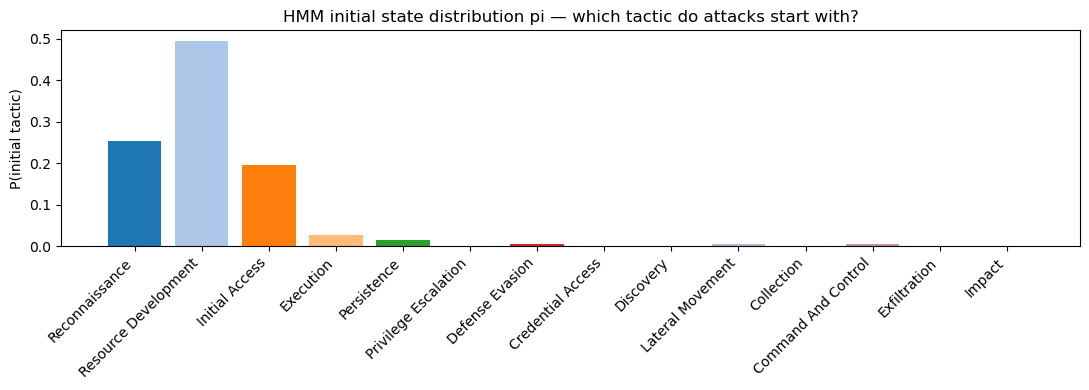

In [14]:
# Initial probability vector — bar plot.
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(n_states), pi, color=[TACTIC_COLORS[t] for t in CANONICAL_TACTICS])
ax.set_xticks(range(n_states))
ax.set_xticklabels([TACTIC_DISPLAY[t] for t in CANONICAL_TACTICS], rotation=45, ha="right")
ax.set_ylabel("P(initial tactic)")
ax.set_title("HMM initial state distribution pi — which tactic do attacks start with?")
plt.tight_layout()
plt.show()


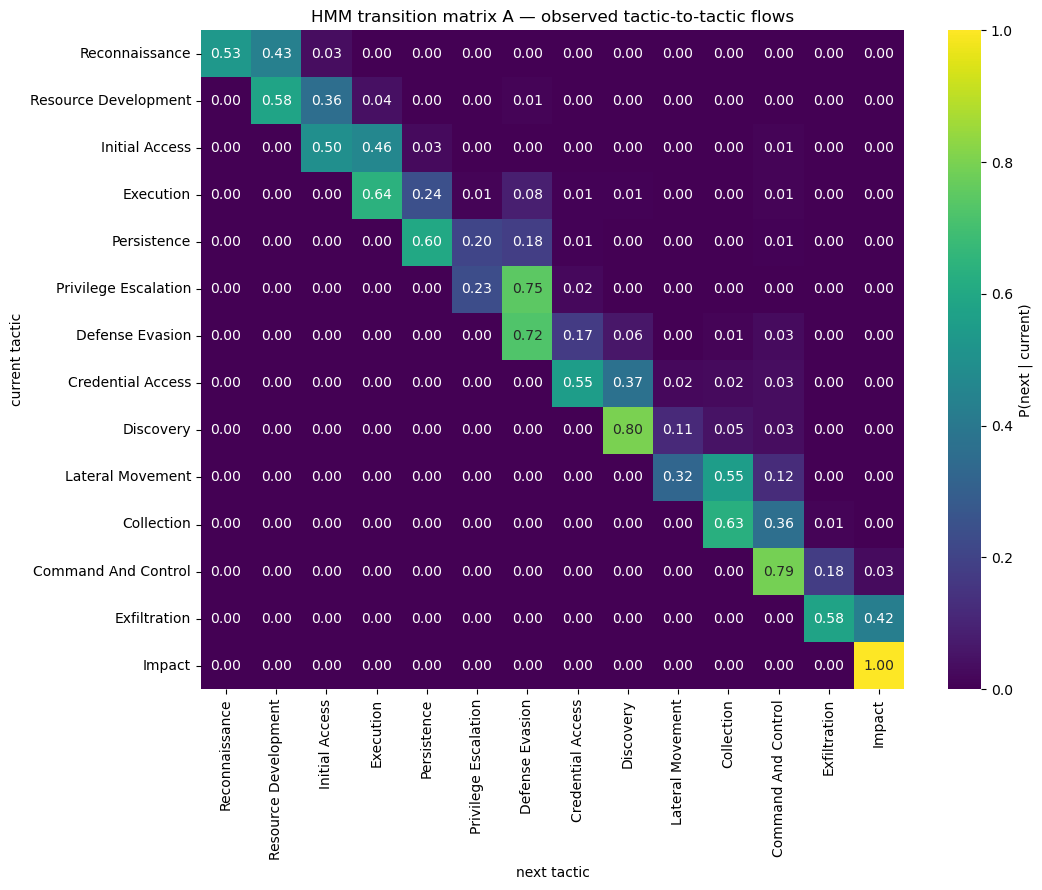

In [15]:
# Transition matrix heatmap (14x14).
labels = [TACTIC_DISPLAY[t] for t in CANONICAL_TACTICS]
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(A_prob, annot=True, fmt=".2f", cmap="viridis",
            xticklabels=labels, yticklabels=labels, cbar_kws={"label": "P(next | current)"}, ax=ax)
ax.set_xlabel("next tactic")
ax.set_ylabel("current tactic")
ax.set_title("HMM transition matrix A — observed tactic-to-tactic flows")
plt.tight_layout()
plt.show()


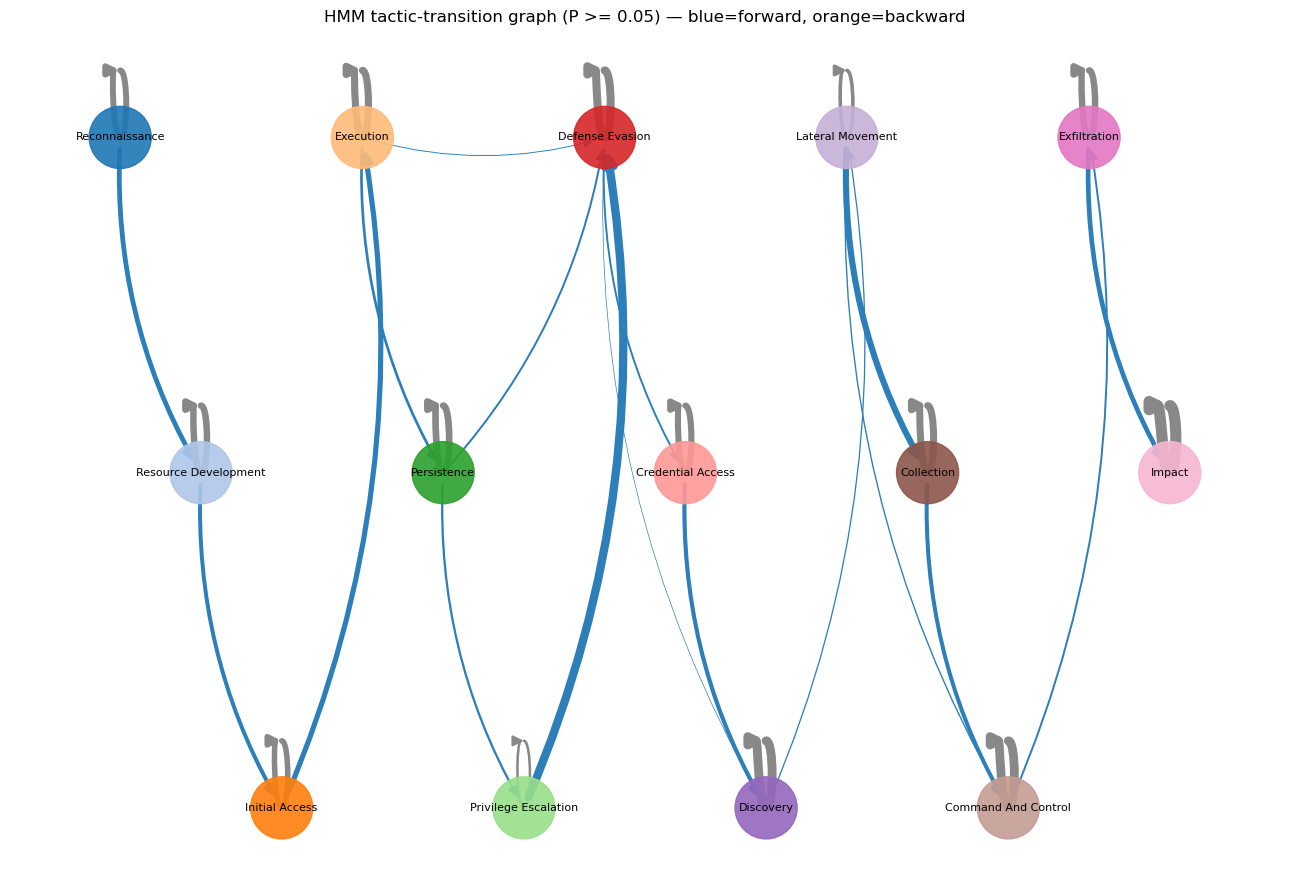

In [16]:
# Directed graph of tactic transitions (filter prob < 0.05).
THRESHOLD = 0.05
G_hmm = nx.DiGraph()
for i, src in enumerate(CANONICAL_TACTICS):
    G_hmm.add_node(src, layer=i)
for i, src in enumerate(CANONICAL_TACTICS):
    for j, dst in enumerate(CANONICAL_TACTICS):
        if A_prob[i, j] >= THRESHOLD:
            G_hmm.add_edge(src, dst, weight=A_prob[i, j])

fig, ax = plt.subplots(figsize=(13, 9))
pos = {t: (TACTIC_LAYER[t], -((TACTIC_LAYER[t] % 3))) for t in CANONICAL_TACTICS}
node_colors = [TACTIC_COLORS[n] for n in G_hmm.nodes]
edge_widths = [G_hmm[u][v]["weight"] * 8 for u, v in G_hmm.edges]
edge_colors = ["#2c7fb8" if TACTIC_LAYER[u] < TACTIC_LAYER[v]
               else "#d95f02" if TACTIC_LAYER[u] > TACTIC_LAYER[v]
               else "#888888" for u, v in G_hmm.edges]

nx.draw_networkx_nodes(G_hmm, pos, node_size=2000, node_color=node_colors, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G_hmm, pos, width=edge_widths, edge_color=edge_colors,
                       connectionstyle="arc3,rad=0.15", arrows=True, arrowsize=15, ax=ax)
nx.draw_networkx_labels(G_hmm, pos, labels={t: TACTIC_DISPLAY[t] for t in G_hmm.nodes},
                        font_size=8, ax=ax)
ax.set_title(f"HMM tactic-transition graph (P >= {THRESHOLD}) — blue=forward, orange=backward")
ax.axis("off")
plt.tight_layout()
plt.show()


In [17]:
# Promote tactic-level transitions into technique-level candidate edges.
# For each transition (T_src -> T_dst) above threshold, take the top-k emitted techniques on each side
# and produce all pairs. This is the "tactic+emission" composition strategy.
TOP_K = 3
HMM_THRESHOLD = 0.10
hmm_edges = {}
for i, src_tactic in enumerate(CANONICAL_TACTICS):
    for j, dst_tactic in enumerate(CANONICAL_TACTICS):
        if A_prob[i, j] < HMM_THRESHOLD:
            continue
        src_techs = sorted(B.get(src_tactic, {}).items(), key=lambda kv: -kv[1])[:TOP_K]
        dst_techs = sorted(B.get(dst_tactic, {}).items(), key=lambda kv: -kv[1])[:TOP_K]
        for s_tid, s_p in src_techs:
            for d_tid, d_p in dst_techs:
                if s_tid == d_tid:
                    continue
                key = (s_tid, d_tid)
                score = A_prob[i, j] * s_p * d_p
                # keep highest-scoring derivation if duplicate
                if key not in hmm_edges or hmm_edges[key]["score"] < score:
                    hmm_edges[key] = {
                        "transition_prob": float(A_prob[i, j]),
                        "src_emission": s_p,
                        "dst_emission": d_p,
                        "score": score,
                        "tactic_pair": f"{TACTIC_DISPLAY[src_tactic]} -> {TACTIC_DISPLAY[dst_tactic]}",
                    }

print(f"HMM-derived candidate technique edges: {len(hmm_edges):,}")
top_hmm = sorted(hmm_edges.items(), key=lambda kv: -kv[1]["score"])[:15]
print("\nTop 15 HMM-derived edges by composed score:")
for (s, d), meta in top_hmm:
    print(f"  {s} {name_of(s)[:25]:<25} -> {d} {name_of(d)[:25]:<25}  "
          f"P_trans={meta['transition_prob']:.2f}  score={meta['score']:.4f}")


HMM-derived candidate technique edges: 219

Top 15 HMM-derived edges by composed score:
  T1021 Remote Services           -> T1560 Archive Collected Data     P_trans=0.55  score=0.0706
  T1021 Remote Services           -> T1005 Data from Local System     P_trans=0.55  score=0.0682
  T1041 Exfiltration Over C2 Chan -> T1567 Exfiltration Over Web Ser  P_trans=0.58  score=0.0572
  T1567 Exfiltration Over Web Ser -> T1041 Exfiltration Over C2 Chan  P_trans=0.58  score=0.0572
  T1021 Remote Services           -> T1074 Data Staged                P_trans=0.55  score=0.0562
  T1055 Process Injection         -> T1027 Obfuscated Files or Infor  P_trans=0.75  score=0.0544
  T1055 Process Injection         -> T1036 Masquerading               P_trans=0.75  score=0.0520
  T1486 Data Encrypted for Impact -> T1657 Financial Theft            P_trans=1.00  score=0.0457
  T1657 Financial Theft           -> T1486 Data Encrypted for Impact  P_trans=1.00  score=0.0457
  T1566 Phishing                  -> T1

**Key output for the GAP.** Two things:

1. **Validation of layer ordering.** The transition matrix heatmap shows where observed flows diverge from canonical ordering. Strong forward bands (lower-left to upper-right) confirm the layering; orange backward edges in the graph plot reveal where the canonical ordering oversimplifies real adversary behaviour and where the GAP's `is_backward` flag will see use.
2. **Candidate technique edges.** `hmm_edges` is the second source of candidate edges for the GAP. Note that these are *derived* (composed from tactic-level transitions and within-tactic emissions), so confidence is lower than for §2 / §4 / §5 — the HMM is most useful for ordering validation, less so as a direct edge generator.


---

## Section 4 — DeepOP-style Ontology Reasoning (Simplified)

> Zhang, Y. et al. *DeepOP: Ontological Precondition Extraction for ATT&CK Techniques.*

**Method (simplified).** For each ATT&CK technique, parse its description text from the STIX bundle. Search for explicit precondition language ("requires", "after", "following", "depends on", "leveraging", "with access to", "once X is achieved"). When such language references another identifiable technique (by name match or T-id), record an edge. Also parse the `x_mitre_prerequisites` field where present.

**What this gives the GAP.** These are the highest-quality automated edges in the notebook because they have a *documentation citation*. The catch is recall — explicit precondition language is rare in MITRE descriptions, so this method finds ~10s of edges, not 1000s. That is fine: in the GAP design (Phase 2a), these become a seed set that primes manual annotation.


In [18]:
# Build a name -> technique_id index for fuzzy in-text matching.
# Lowercase, drop punctuation; longer names first to prefer most specific match.
name_to_id = {}
for tid, rec in techniques.items():
    if rec.get("name"):
        name_to_id[rec["name"].lower()] = tid

# Pre-sort names by length (longest first) so we prefer "valid accounts" over "accounts"
sorted_names = sorted(name_to_id.keys(), key=len, reverse=True)

# Patterns that suggest a precondition follows.
PRECONDITION_PATTERNS = [
    r"requires?\b",
    r"after (?:the|an?|having|gaining)\b",
    r"following\s+(?:a|the|an?)\b",
    r"depends? on\b",
    r"leveraging\b",
    r"using credentials? (?:obtained|gained|acquired)\b",
    r"with access to\b",
    r"once\s+(?:[A-Z][\w\s]{1,40}?)(?: is| has been| was)\s+(?:achieved|established|completed|obtained)",
    r"prior to\b",
    r"before\b",
    r"prerequisite",
]
PATTERN_RE = re.compile("|".join(PRECONDITION_PATTERNS), re.IGNORECASE)
TID_RE = re.compile(r"\bT\d{4}(?:\.\d{3})?\b")

def find_techniques_in_text(text, exclude_tid):
    """Return list of (tid, snippet, match_kind) found in text."""
    hits = []
    text_lc = text.lower()

    # 1. Direct T-id mentions
    for m in TID_RE.finditer(text):
        tid = parent_technique_id(m.group())
        if tid and tid != exclude_tid and tid in techniques:
            start = max(0, m.start() - 60)
            end = min(len(text), m.end() + 60)
            hits.append((tid, text[start:end].strip(), "tid_match"))

    # 2. Technique name mentions (longest match first, no overlap)
    used_spans = []
    for name in sorted_names:
        if len(name) < 6:  # avoid trivial matches
            continue
        idx = 0
        while True:
            pos = text_lc.find(name, idx)
            if pos == -1:
                break
            end = pos + len(name)
            # avoid overlaps with already-claimed spans
            if not any(s <= pos < e or s < end <= e for s, e in used_spans):
                tid = name_to_id[name]
                if tid != exclude_tid:
                    snippet = text[max(0, pos - 60):min(len(text), end + 60)]
                    hits.append((tid, snippet.strip(), "name_match"))
                    used_spans.append((pos, end))
            idx = end
    return hits

print(f"Precondition patterns: {len(PRECONDITION_PATTERNS)}")
print(f"Searchable names: {len(name_to_id)}")


Precondition patterns: 11
Searchable names: 216


In [19]:
# Walk every technique description, sentence by sentence, looking for precondition cues + tech mentions.
ontology_edges = {}
SENTENCE_SPLIT = re.compile(r"(?<=[.!?])\s+")

for target_tid, rec in techniques.items():
    desc = rec.get("description", "") or ""

    # Path 1: x_mitre_prerequisites field, if any.
    for prereq in rec.get("x_mitre_prerequisites", []) or []:
        for src_tid, snippet, kind in find_techniques_in_text(prereq, target_tid):
            key = (src_tid, target_tid)
            ontology_edges.setdefault(key, []).append({
                "evidence": "x_mitre_prerequisites",
                "snippet": snippet[:200],
                "match_kind": kind,
            })

    # Path 2: precondition language inside the description.
    for sent in SENTENCE_SPLIT.split(desc):
        if not PATTERN_RE.search(sent):
            continue
        for src_tid, snippet, kind in find_techniques_in_text(sent, target_tid):
            key = (src_tid, target_tid)
            ontology_edges.setdefault(key, []).append({
                "evidence": "description_pattern",
                "snippet": snippet[:200],
                "match_kind": kind,
            })

print(f"Extracted {len(ontology_edges)} ontology edges from "
      f"{len(techniques)} technique descriptions.")

evidence_kinds = Counter()
for evs in ontology_edges.values():
    for e in evs:
        evidence_kinds[e["evidence"]] += 1
print("\nBreakdown by evidence source:")
for k, v in evidence_kinds.items():
    print(f"  {k}: {v}")


Extracted 52 ontology edges from 216 technique descriptions.

Breakdown by evidence source:
  description_pattern: 83


In [20]:
# Print all extracted edges with their justifying snippets.
print(f"All {len(ontology_edges)} ontology-extracted edges:\n")
for i, ((src, dst), evs) in enumerate(sorted(ontology_edges.items()), 1):
    e = evs[0]
    print(f"{i:3}. {src} {name_of(src)[:30]:<30} -> {dst} {name_of(dst)[:30]:<30}")
    print(f"     [{e['evidence']} / {e['match_kind']}]  ...{e['snippet'][:160]}...")
    if i >= 30:
        print(f"     ... ({len(ontology_edges) - 30} more edges)")
        break


All 52 ontology-extracted edges:

  1. T1003 OS Credential Dumping          -> T1110 Brute Force                   
     [description_pattern / tid_match]  ...[OS Credential Dumping](https://attack.mitre.org/techniques/T1003), [Account Discovery](https://attack.mitre.org/techniques/T...
  2. T1003 OS Credential Dumping          -> T1485 Data Destruction              
     [description_pattern / tid_match]  ...[OS Credential Dumping](https://attack.mitre.org/techniques/T1003), and [SMB/Windows Admin Shares](https://attack.mitre.org/t...
  3. T1003 OS Credential Dumping          -> T1486 Data Encrypted for Impact     
     [description_pattern / tid_match]  ...[OS Credential Dumping](https://attack.mitre.org/techniques/T1003), and [SMB/Windows Admin Shares](https://attack.mitre.org/t...
  4. T1003 OS Credential Dumping          -> T1561 Disk Wipe                     
     [description_pattern / tid_match]  ...[OS Credential Dumping](https://attack.mitre.org/techniques/T1003), and [SMB/Wi

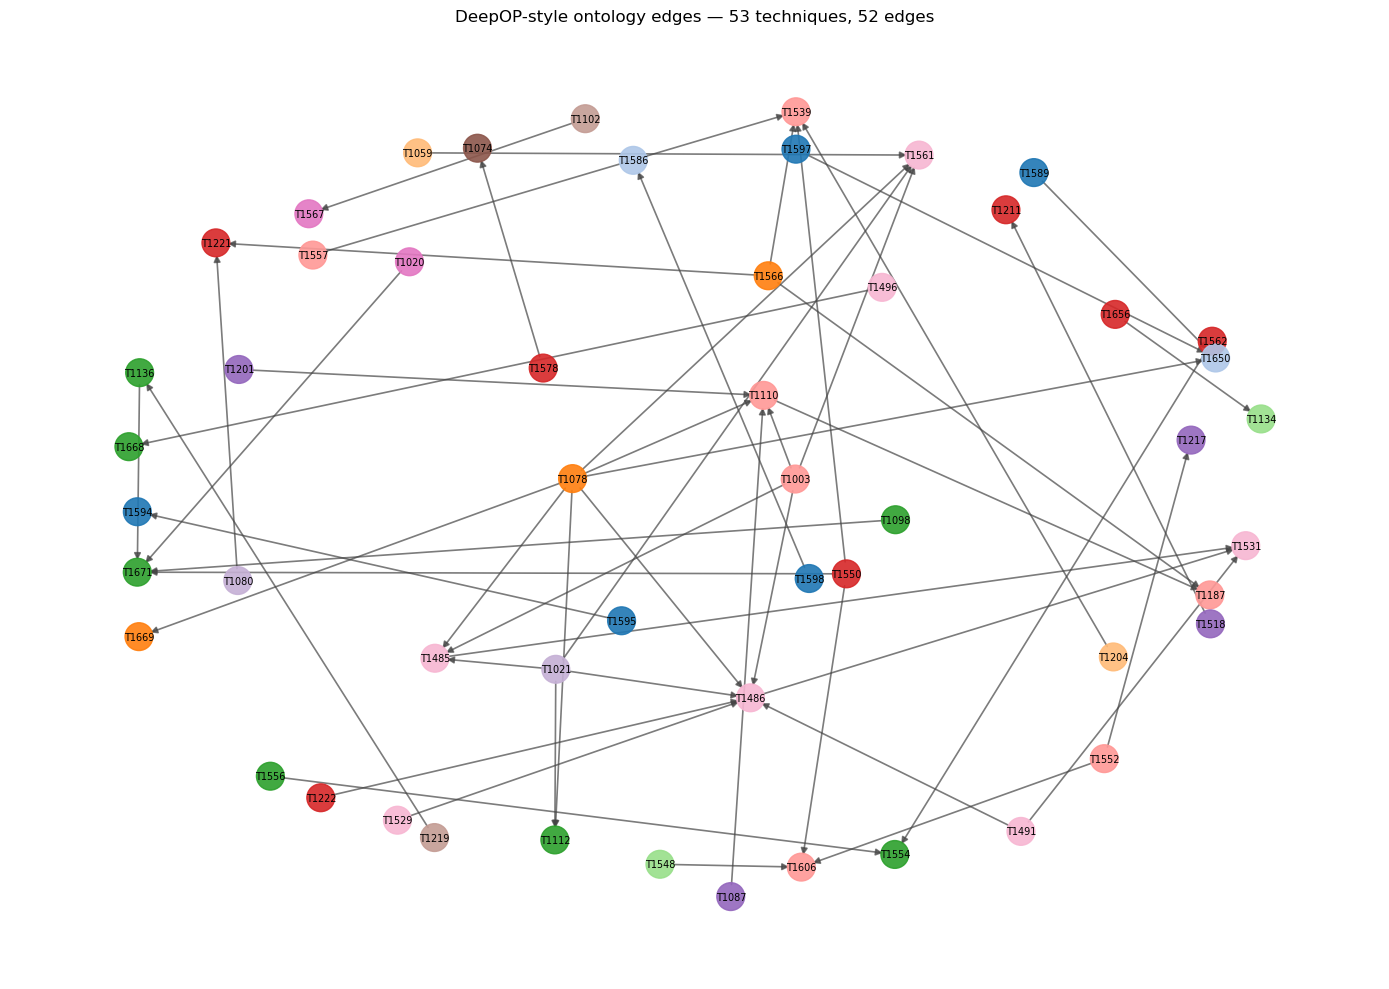

In [21]:
# Visualise the extracted dependency edges, coloured by source-tactic layer.
G_onto = nx.DiGraph()
for (src, dst), evs in ontology_edges.items():
    G_onto.add_node(src, tactic=tactic_of(src))
    G_onto.add_node(dst, tactic=tactic_of(dst))
    G_onto.add_edge(src, dst, count=len(evs))

if len(G_onto) > 0:
    fig, ax = plt.subplots(figsize=(14, 10))
    pos = nx.spring_layout(G_onto, k=1.0, seed=7)
    node_colors = [TACTIC_COLORS.get(G_onto.nodes[n].get("tactic"), "#888") for n in G_onto.nodes]
    nx.draw_networkx_nodes(G_onto, pos, node_size=400, node_color=node_colors, alpha=0.9, ax=ax)
    nx.draw_networkx_edges(G_onto, pos, edge_color="#444", width=1.2, alpha=0.7,
                           arrows=True, arrowsize=10, ax=ax)
    nx.draw_networkx_labels(G_onto, pos, font_size=7, ax=ax)
    ax.set_title(f"DeepOP-style ontology edges — {len(G_onto.nodes)} techniques, {len(G_onto.edges)} edges")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No ontology edges to visualise.")


**Key output for the GAP.** `ontology_edges` is the smallest but highest-evidence set in the notebook — every entry has a documentation citation. In the GAP construction algorithm (Phase 2a), these become the seed set: edges that pass straight through to the global graph with `evidence_type="documentation"` and a snippet stored in the Evidence record.

---

## Section 5 — Attack Flow Corpus Import (AttacKG+ style)

> MITRE Center for Threat-Informed Defense — *Attack Flow*.

**Method.** Skip the LLM pipeline from AttacKG+; instead consume MITRE's manually curated **Attack Flow** corpus. Each flow is a JSON file describing a real campaign as a DAG of "actions" (each tagged with an ATT&CK technique). The transitions between actions are exactly the technique-to-technique edges the GAP needs.

**What this gives the GAP.** These are the highest-fidelity edges available — manually authored by MITRE analysts. In the GAP they get `evidence_type="attack_flow"` and skip manual review.

If the corpus cannot be downloaded (offline / network blocked), this section logs and skips, leaving `flow_edges` empty.


In [22]:
# Try to load the Attack Flow corpus. Local first, then GitHub tarball.
import io
import tarfile
import urllib.request

ATTACK_FLOW_LOCAL = NOTEBOOK_DIR / "attack-flow"
ATTACK_FLOW_TARBALL = "https://github.com/center-for-threat-informed-defense/attack-flow/archive/refs/heads/main.tar.gz"

flow_files = []

if ATTACK_FLOW_LOCAL.exists():
    print(f"Using local corpus: {ATTACK_FLOW_LOCAL}")
    flow_files = sorted(ATTACK_FLOW_LOCAL.rglob("corpus/*.json"))
    if not flow_files:
        flow_files = sorted(ATTACK_FLOW_LOCAL.rglob("*.json"))
else:
    print(f"Local corpus not found, attempting download from {ATTACK_FLOW_TARBALL} ...")
    try:
        with urllib.request.urlopen(ATTACK_FLOW_TARBALL, timeout=60) as resp:
            data = resp.read()
        with tarfile.open(fileobj=io.BytesIO(data), mode="r:gz") as tf:
            ATTACK_FLOW_LOCAL.mkdir(exist_ok=True)
            tf.extractall(ATTACK_FLOW_LOCAL)
        flow_files = sorted(ATTACK_FLOW_LOCAL.rglob("corpus/*.json"))
        if not flow_files:
            flow_files = sorted(ATTACK_FLOW_LOCAL.rglob("*.afb")) + sorted(ATTACK_FLOW_LOCAL.rglob("*.json"))
        print(f"Downloaded and extracted to {ATTACK_FLOW_LOCAL}")
    except Exception as e:
        print(f"  ! Download failed ({e}). Section 5 will run with an empty flow corpus.")

print(f"\nFlow files discovered: {len(flow_files)}")
for fp in flow_files[:5]:
    print(f"  {fp.relative_to(NOTEBOOK_DIR) if NOTEBOOK_DIR in fp.parents else fp}")
if len(flow_files) > 5:
    print(f"  ... and {len(flow_files) - 5} more")


Using local corpus: /home/marc/GitHub/MTDSim/notebooks/attack-flow

Flow files discovered: 77
  attack-flow/attack-flow-main/.vscode/extensions.json
  attack-flow/attack-flow-main/.vscode/settings.json
  attack-flow/attack-flow-main/src/attack_flow_builder/data/enterprise-attack.json
  attack-flow/attack-flow-main/src/attack_flow_builder/data/ics-attack.json
  attack-flow/attack-flow-main/src/attack_flow_builder/data/mobile-attack.json
  ... and 72 more


In [23]:
# Parse Attack Flow files. The corpus uses two related schemas:
#   - "Attack Flow JSON" (STIX-like with attack-action / attack-flow types)
#   - "AFB" Builder format (older). We focus on the Attack Flow JSON.
# Each action node has technique_id; sequencing is encoded via "effect_refs" or
# top-level "start_refs"/"effect_refs".

def parse_attack_flow(path):
    """Return list of (src_tid, dst_tid) edges from one Attack Flow file."""
    try:
        with open(path) as f:
            data = json.load(f)
    except Exception:
        return [], None

    objs = data.get("objects", []) if isinstance(data, dict) else []
    if not objs:
        return [], None

    # Collect actions: stix id -> technique id
    action_tid = {}
    flow_name = None
    for o in objs:
        t = o.get("type")
        if t == "attack-flow":
            flow_name = o.get("name")
        if t == "attack-action":
            tid_full = o.get("technique_id")
            if not tid_full:
                # try external_references
                for ref in o.get("external_references", []) or []:
                    if ref.get("source_name") == "mitre-attack":
                        tid_full = ref.get("external_id")
                        break
            if tid_full:
                action_tid[o["id"]] = parent_technique_id(tid_full)

    # Walk effect_refs to build edges
    edges = []
    for o in objs:
        if o.get("type") == "attack-action":
            src_tid = action_tid.get(o["id"])
            if not src_tid:
                continue
            for ref in o.get("effect_refs", []) or []:
                dst_tid = action_tid.get(ref)
                if dst_tid and dst_tid != src_tid:
                    edges.append((src_tid, dst_tid))

    return edges, flow_name


per_flow_edges = {}  # flow filename -> list of (src, dst)
for fp in flow_files:
    if fp.suffix.lower() != ".json":
        continue
    edges, name = parse_attack_flow(fp)
    if edges:
        per_flow_edges[fp.name] = {"edges": edges, "name": name or fp.stem}

print(f"Parsed flows with at least one technique edge: {len(per_flow_edges)}")
total_raw = sum(len(v["edges"]) for v in per_flow_edges.values())
print(f"Total raw flow edges: {total_raw}")


Parsed flows with at least one technique edge: 5
Total raw flow edges: 8


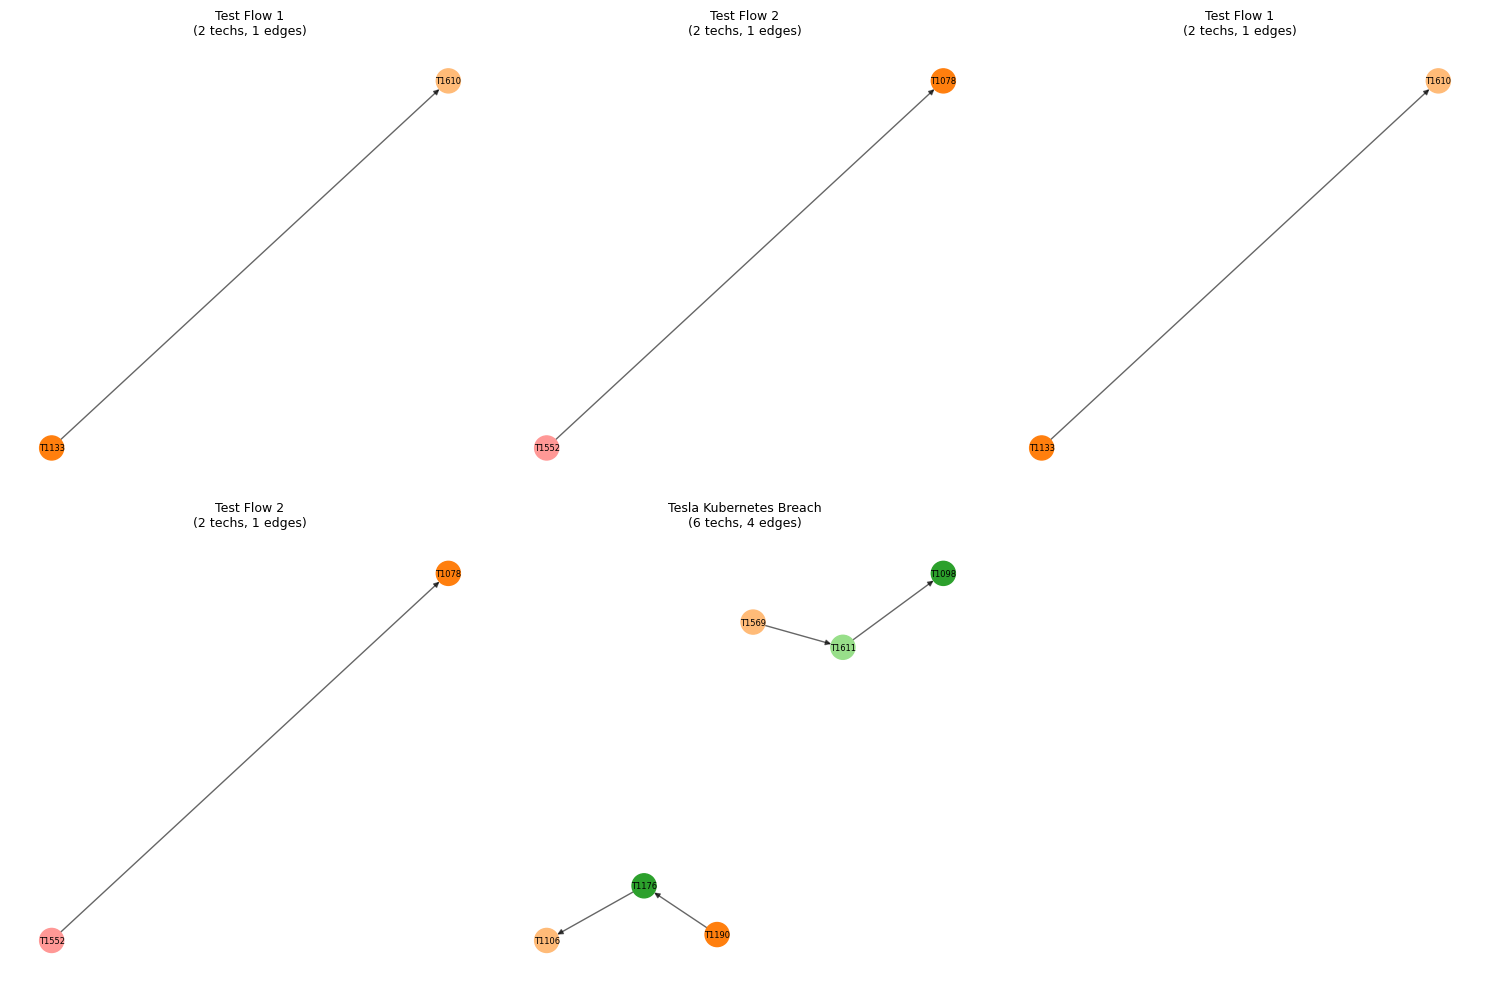

In [24]:
# Visualise the first few flows individually as small DAGs.
import math

if per_flow_edges:
    n_show = min(6, len(per_flow_edges))
    cols = 3
    rows = math.ceil(n_show / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten() if rows * cols > 1 else [axes]

    for ax, (fname, info) in zip(axes, list(per_flow_edges.items())[:n_show]):
        g = nx.DiGraph()
        for s, d in info["edges"]:
            g.add_node(s, tactic=tactic_of(s))
            g.add_node(d, tactic=tactic_of(d))
            g.add_edge(s, d)
        try:
            pos = nx.nx_agraph.graphviz_layout(g, prog="dot")
        except Exception:
            pos = nx.spring_layout(g, seed=2)
        node_colors = [TACTIC_COLORS.get(g.nodes[n].get("tactic"), "#888") for n in g.nodes]
        nx.draw_networkx_nodes(g, pos, node_size=300, node_color=node_colors, ax=ax)
        nx.draw_networkx_edges(g, pos, arrows=True, arrowsize=8, alpha=0.6, ax=ax)
        nx.draw_networkx_labels(g, pos, font_size=6, ax=ax)
        ax.set_title(f"{info['name'][:40]}\n({len(g.nodes)} techs, {len(g.edges)} edges)", fontsize=9)
        ax.axis("off")

    for ax in axes[n_show:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No flows to visualise (corpus unavailable).")


In [25]:
# Aggregate: union all edges across all flows.
flow_edges = {}  # (src, dst) -> {count, sources}
for fname, info in per_flow_edges.items():
    for s, d in info["edges"]:
        key = (s, d)
        if key not in flow_edges:
            flow_edges[key] = {"count": 0, "sources": []}
        flow_edges[key]["count"] += 1
        flow_edges[key]["sources"].append(info["name"])

unique_techs = {t for e in flow_edges for t in e}
covered_tactics = Counter()
for tid in unique_techs:
    rec = techniques.get(tid)
    if rec and rec["primary_tactic"]:
        covered_tactics[rec["primary_tactic"]] += 1

print(f"Aggregated unique edges: {len(flow_edges)}")
print(f"Unique techniques in corpus: {len(unique_techs)}")
print("\nTactic coverage in Attack Flow corpus:")
for t in CANONICAL_TACTICS:
    n = covered_tactics.get(t, 0)
    bar = "#" * n
    print(f"  {TACTIC_DISPLAY[t]:<22}  {n:>3}  {bar}")


Aggregated unique edges: 6
Unique techniques in corpus: 10

Tactic coverage in Attack Flow corpus:
  Reconnaissance            0  
  Resource Development      0  
  Initial Access            3  ###
  Execution                 3  ###
  Persistence               2  ##
  Privilege Escalation      1  #
  Defense Evasion           0  
  Credential Access         1  #
  Discovery                 0  
  Lateral Movement          0  
  Collection                0  
  Command And Control       0  
  Exfiltration              0  
  Impact                    0  


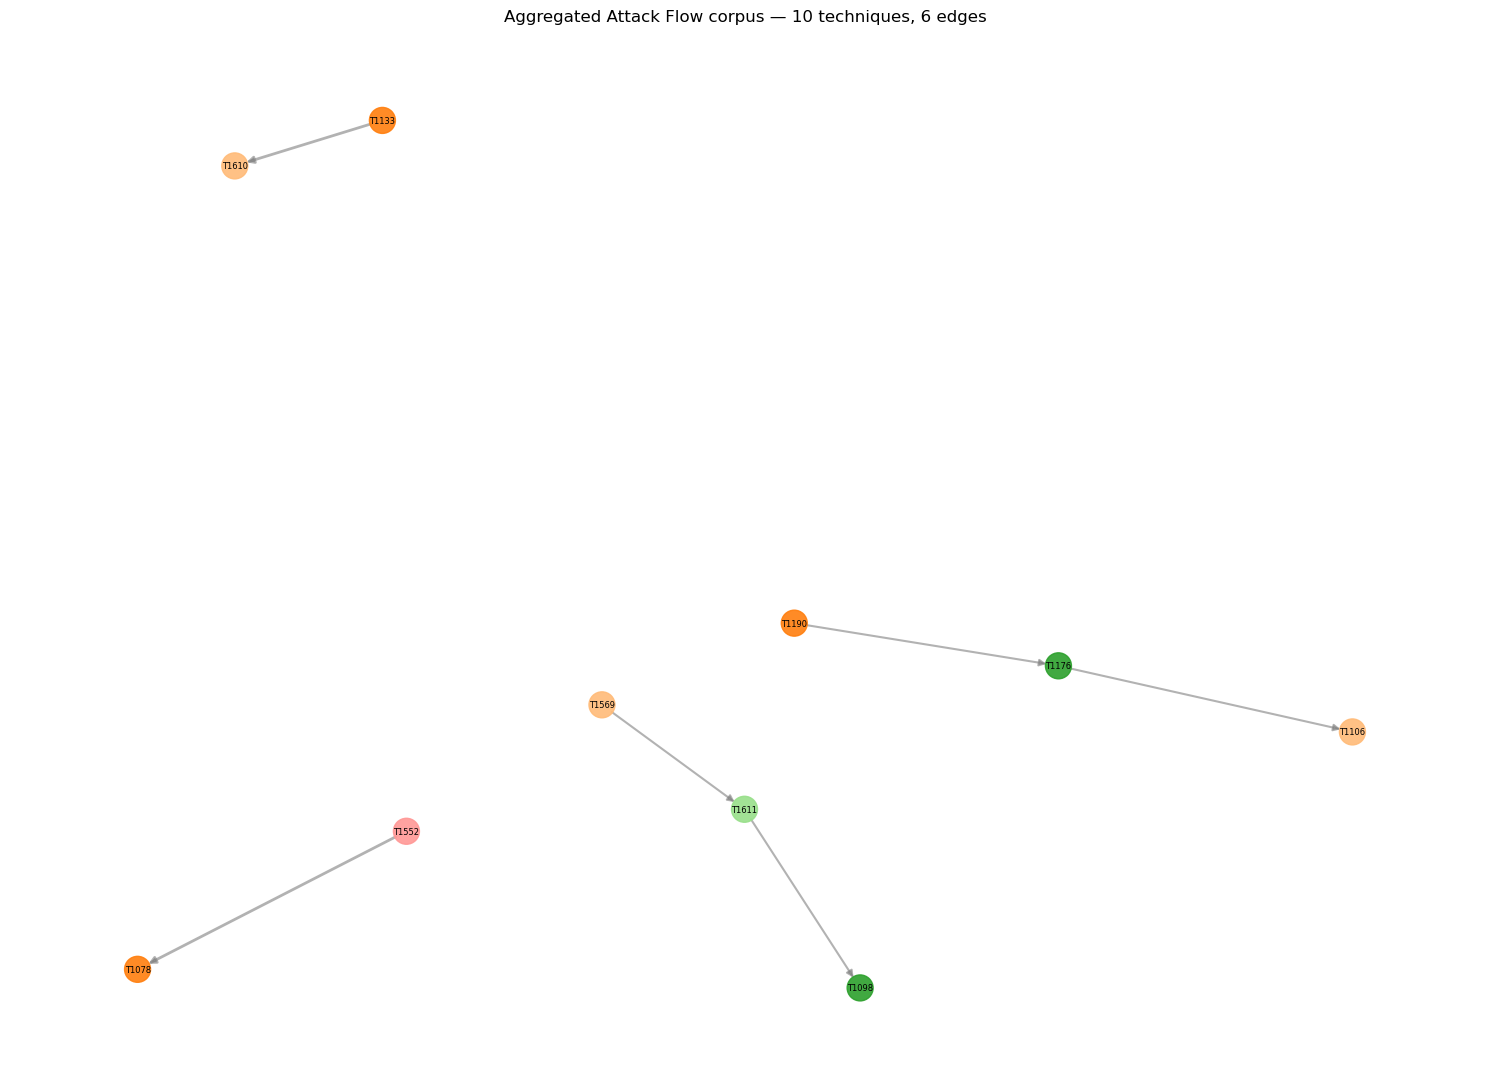

In [26]:
# Visualise the aggregated flow graph.
if flow_edges:
    G_flow = nx.DiGraph()
    for (s, d), meta in flow_edges.items():
        G_flow.add_node(s, tactic=tactic_of(s))
        G_flow.add_node(d, tactic=tactic_of(d))
        G_flow.add_edge(s, d, count=meta["count"])

    fig, ax = plt.subplots(figsize=(15, 11))
    try:
        pos = nx.nx_agraph.graphviz_layout(G_flow, prog="dot")
    except Exception:
        pos = nx.spring_layout(G_flow, k=0.4, seed=3)
    node_colors = [TACTIC_COLORS.get(G_flow.nodes[n].get("tactic"), "#888") for n in G_flow.nodes]
    edge_widths = [1 + 0.5 * G_flow[u][v]["count"] for u, v in G_flow.edges]
    nx.draw_networkx_nodes(G_flow, pos, node_size=350, node_color=node_colors, alpha=0.9, ax=ax)
    nx.draw_networkx_edges(G_flow, pos, width=edge_widths, edge_color="grey", alpha=0.6,
                           arrows=True, arrowsize=10, ax=ax)
    nx.draw_networkx_labels(G_flow, pos, font_size=6, ax=ax)
    ax.set_title(f"Aggregated Attack Flow corpus — {len(G_flow.nodes)} techniques, {len(G_flow.edges)} edges")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No aggregated graph to draw.")


**Key output for the GAP.** `flow_edges` is the gold-standard candidate set. Each entry inherits MITRE analyst review and gets `evidence_type="attack_flow"` in the GAP. Edges with `count > 1` (the same edge appearing in multiple curated flows) are the highest-confidence subset.

---

## Section 6 — Integration: Comparing All Four Sources

The point of the notebook. Combine the candidate edges from §2, §3, §4, §5 into a single tagged edge set, then ask the question that drives the GAP design: **which edges have multi-source agreement, and how much of the graph is already covered before any manual annotation?**


In [27]:
# Build the unified edge set: each edge gets a set of source tags.
SOURCE_TAGS = ["co_occurrence", "hmm", "ontology", "attack_flow"]

unified = defaultdict(lambda: {"sources": set(), "meta": {}})

for key in cooc_edges:
    unified[key]["sources"].add("co_occurrence")
    unified[key]["meta"]["co_occurrence"] = cooc_edges[key]
for key in hmm_edges:
    unified[key]["sources"].add("hmm")
    unified[key]["meta"]["hmm"] = hmm_edges[key]
for key in ontology_edges:
    unified[key]["sources"].add("ontology")
    unified[key]["meta"]["ontology"] = ontology_edges[key]
for key in flow_edges:
    unified[key]["sources"].add("attack_flow")
    unified[key]["meta"]["attack_flow"] = flow_edges[key]

print(f"Total unified candidate edges: {len(unified):,}")
for src in SOURCE_TAGS:
    n = sum(1 for v in unified.values() if src in v["sources"])
    print(f"  {src:<14}  {n:>5}")
print()
multi = sum(1 for v in unified.values() if len(v["sources"]) >= 2)
print(f"Edges supported by 2+ sources: {multi:,}")
print(f"Edges supported by 3+ sources: {sum(1 for v in unified.values() if len(v['sources']) >= 3):,}")
print(f"Edges supported by all 4:      {sum(1 for v in unified.values() if len(v['sources']) == 4):,}")


Total unified candidate edges: 388
  co_occurrence     128
  hmm               219
  ontology           52
  attack_flow         6

Edges supported by 2+ sources: 17
Edges supported by 3+ sources: 0
Edges supported by all 4:      0


Unified graph: 99 nodes, 388 edges
Draw subset (multi-source backbone): 17 nodes, 92 edges


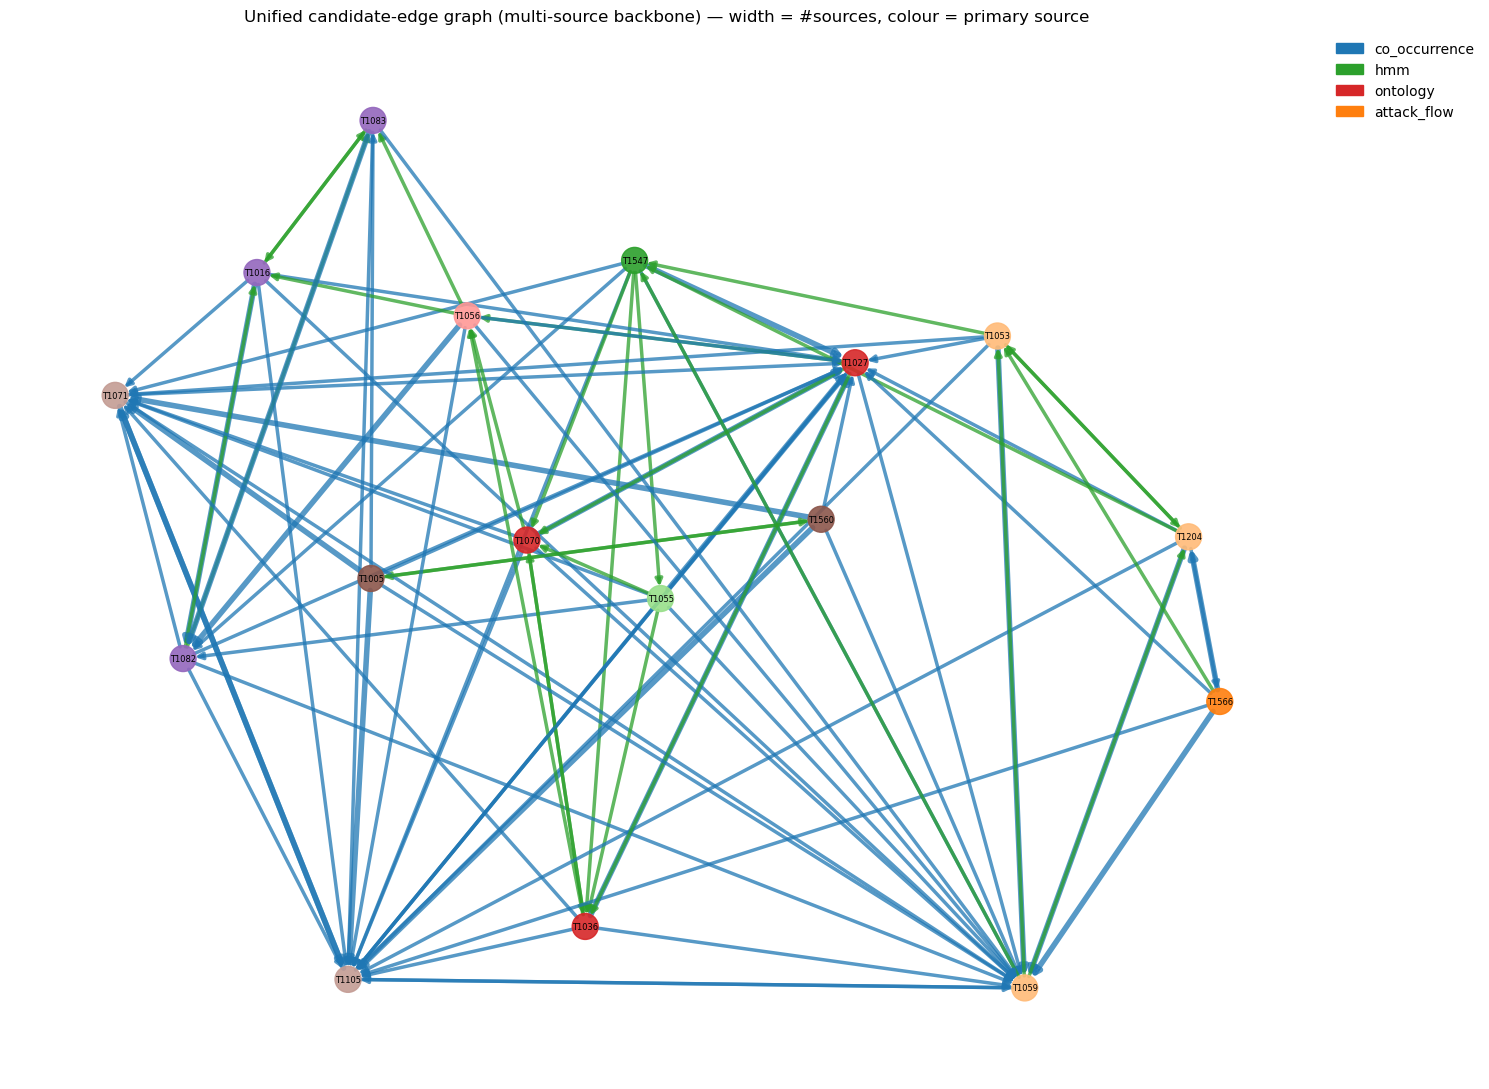

In [28]:
# Combined graph: edges coloured by source, multi-source edges drawn thicker.
SOURCE_COLOR = {
    "co_occurrence": "#1f77b4",  # blue
    "hmm":           "#2ca02c",  # green
    "ontology":      "#d62728",  # red
    "attack_flow":   "#ff7f0e",  # orange
}

G_unified = nx.DiGraph()
for (s, d), meta in unified.items():
    G_unified.add_node(s, tactic=tactic_of(s))
    G_unified.add_node(d, tactic=tactic_of(d))
    G_unified.add_edge(s, d, sources=tuple(sorted(meta["sources"])), n_sources=len(meta["sources"]))

# Draw a manageable subgraph: only multi-source edges + high-degree nodes from single-source edges.
# Otherwise the figure becomes unreadable for large unified sets.
multi_edges = [(u, v) for u, v, d in G_unified.edges(data=True) if d["n_sources"] >= 2]
sub_nodes = {n for e in multi_edges for n in e}
G_draw = G_unified.subgraph(sub_nodes).copy() if sub_nodes else G_unified

print(f"Unified graph: {G_unified.number_of_nodes()} nodes, {G_unified.number_of_edges()} edges")
print(f"Draw subset (multi-source backbone): {G_draw.number_of_nodes()} nodes, "
      f"{G_draw.number_of_edges()} edges")

fig, ax = plt.subplots(figsize=(15, 11))
pos = nx.spring_layout(G_draw, k=0.7, seed=42) if G_draw.number_of_nodes() else {}
node_colors = [TACTIC_COLORS.get(G_draw.nodes[n].get("tactic"), "#888") for n in G_draw.nodes]
nx.draw_networkx_nodes(G_draw, pos, node_size=350, node_color=node_colors, alpha=0.9, ax=ax)

# Draw each edge with the colour of its first source; use width = number of sources.
for u, v, d in G_draw.edges(data=True):
    primary = d["sources"][0]
    nx.draw_networkx_edges(G_draw, pos, edgelist=[(u, v)],
                           edge_color=SOURCE_COLOR[primary],
                           width=1 + 1.5 * d["n_sources"], alpha=0.75,
                           arrows=True, arrowsize=10, ax=ax)
nx.draw_networkx_labels(G_draw, pos, font_size=6, ax=ax)

from matplotlib.patches import Patch
legend = [Patch(color=c, label=s) for s, c in SOURCE_COLOR.items()]
ax.legend(handles=legend, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
ax.set_title("Unified candidate-edge graph (multi-source backbone) — width = #sources, colour = primary source")
ax.axis("off")
plt.tight_layout()
plt.show()


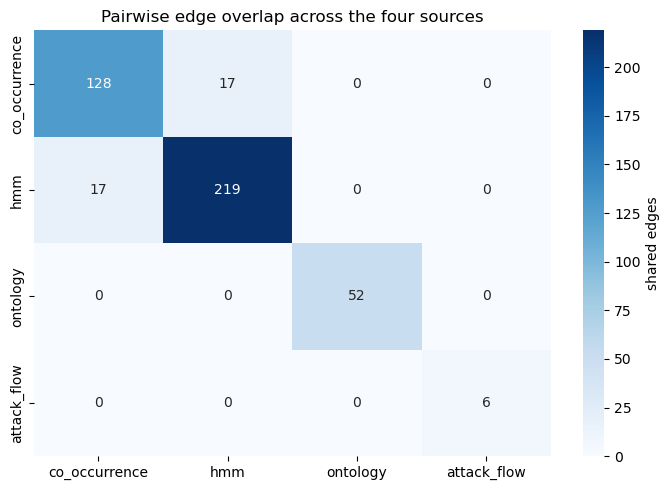

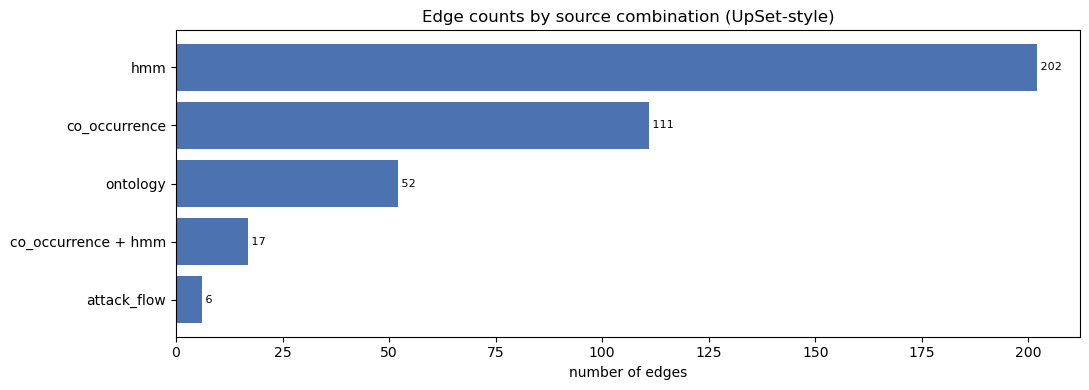

In [29]:
# Overlap statistics + UpSet-style plot of source intersections.
from itertools import combinations

source_sets = {s: {k for k, v in unified.items() if s in v["sources"]} for s in SOURCE_TAGS}

# Pairwise overlap matrix
overlap = pd.DataFrame(0, index=SOURCE_TAGS, columns=SOURCE_TAGS)
for a in SOURCE_TAGS:
    for b in SOURCE_TAGS:
        overlap.loc[a, b] = len(source_sets[a] & source_sets[b])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(overlap, annot=True, fmt="d", cmap="Blues",
            cbar_kws={"label": "shared edges"}, ax=ax)
ax.set_title("Pairwise edge overlap across the four sources")
plt.tight_layout()
plt.show()

# Combination counts (UpSet-flavoured bar plot)
combo_counts = Counter()
for v in unified.values():
    combo_counts[tuple(sorted(v["sources"]))] += 1

combos_sorted = sorted(combo_counts.items(), key=lambda kv: -kv[1])
labels = [" + ".join(c) for c, _ in combos_sorted]
counts = [n for _, n in combos_sorted]

fig, ax = plt.subplots(figsize=(11, max(4, 0.4 * len(combos_sorted))))
ax.barh(labels, counts, color="#4c72b0")
ax.invert_yaxis()
ax.set_xlabel("number of edges")
ax.set_title("Edge counts by source combination (UpSet-style)")
for i, c in enumerate(counts):
    ax.text(c, i, f" {c}", va="center", fontsize=8)
plt.tight_layout()
plt.show()


In [30]:
# Print consensus edges (2+ sources): the highest-confidence GAP candidates.
consensus = [(k, v) for k, v in unified.items() if len(v["sources"]) >= 2]
consensus.sort(key=lambda kv: (-len(kv[1]["sources"]), kv[0]))

print(f"Consensus edges (2+ sources): {len(consensus)}\n")
print(f"{'#':>3}  {'src':<8} -> {'dst':<8}  {'srcs':<6}  source set")
print("-" * 100)
for i, ((s, d), v) in enumerate(consensus[:50], 1):
    sn, dn = name_of(s)[:24], name_of(d)[:24]
    srcs = ", ".join(sorted(v["sources"]))
    print(f"{i:>3}  {s:<8} -> {d:<8}  {len(v['sources']):<6}  [{srcs}]")
    print(f"     {sn:<28} -> {dn}")
if len(consensus) > 50:
    print(f"\n... and {len(consensus) - 50} more consensus edges.")


Consensus edges (2+ sources): 17

  #  src      -> dst       srcs    source set
----------------------------------------------------------------------------------------------------
  1  T1005    -> T1071     2       [co_occurrence, hmm]
     Data from Local System       -> Application Layer Protoc
  2  T1005    -> T1105     2       [co_occurrence, hmm]
     Data from Local System       -> Ingress Tool Transfer
  3  T1016    -> T1082     2       [co_occurrence, hmm]
     System Network Configura     -> System Information Disco
  4  T1036    -> T1027     2       [co_occurrence, hmm]
     Masquerading                 -> Obfuscated Files or Info
  5  T1053    -> T1059     2       [co_occurrence, hmm]
     Scheduled Task/Job           -> Command and Scripting In
  6  T1055    -> T1027     2       [co_occurrence, hmm]
     Process Injection            -> Obfuscated Files or Info
  7  T1056    -> T1082     2       [co_occurrence, hmm]
     Input Capture                -> System Information Di

**Key output for the GAP.** Three things:

1. **Consensus edges** (2+ sources): the highest-confidence dependency set. These should pass straight into the GAP without manual review, with `evidence` records citing each contributing source.
2. **Single-source edges**: needed for full coverage, but each requires verification before entering the GAP. The Venn/UpSet plot shows how lopsided the contribution is — if any one source is dominant, the GAP risks inheriting that source's biases.
3. **Source-disjoint edges**: edges that *only* one source produces tell us about the per-source recall. A method that finds many unique edges is contributing real signal; a method whose edges are entirely a subset of another is redundant.


---

## Section 7 — Coverage Analysis vs. the GAP Node Set

The GAP node set is *all* enterprise techniques arranged by tactic layer (Phase 1 of the construction algorithm in the design schema). Section 6 produced a candidate edge set; this section overlays it onto the GAP node set to answer:

1. **What fraction of techniques are touched by at least one candidate edge?**
2. **Which techniques are still orphans?** (no incoming, no outgoing)
3. **Which orphans should I annotate first?** (rank by `campaign_count` so the most-used techniques get priority — matches the GAP design's prioritisation rule)


In [31]:
# Build the GAP node set as the design schema specifies it.
gap_nodes = pd.DataFrame([
    {
        "technique_id": tid,
        "name": rec["name"],
        "primary_tactic": rec["primary_tactic"],
        "tactic_layer": rec["tactic_layer"],
        "campaign_count": rec["campaign_count"],
    }
    for tid, rec in techniques.items()
    if rec["primary_tactic"] is not None
])
print(f"GAP node set: {len(gap_nodes)} techniques across {gap_nodes['primary_tactic'].nunique()} tactics")

# Coverage from the unified edge set
covered_in = {d for (s, d) in unified}
covered_out = {s for (s, d) in unified}
covered_any = covered_in | covered_out

n = len(gap_nodes)
in_deg_pct = 100 * sum(1 for t in gap_nodes.technique_id if t in covered_in) / n
out_deg_pct = 100 * sum(1 for t in gap_nodes.technique_id if t in covered_out) / n
any_pct = 100 * sum(1 for t in gap_nodes.technique_id if t in covered_any) / n

print(f"\n{'Coverage from unified candidate edges:':<45}")
print(f"  Techniques with >=1 incoming edge:  {in_deg_pct:5.1f}%")
print(f"  Techniques with >=1 outgoing edge:  {out_deg_pct:5.1f}%")
print(f"  Techniques with any edge:           {any_pct:5.1f}%")


GAP node set: 216 techniques across 14 tactics

Coverage from unified candidate edges:       
  Techniques with >=1 incoming edge:   30.6%
  Techniques with >=1 outgoing edge:   38.4%
  Techniques with any edge:            45.8%


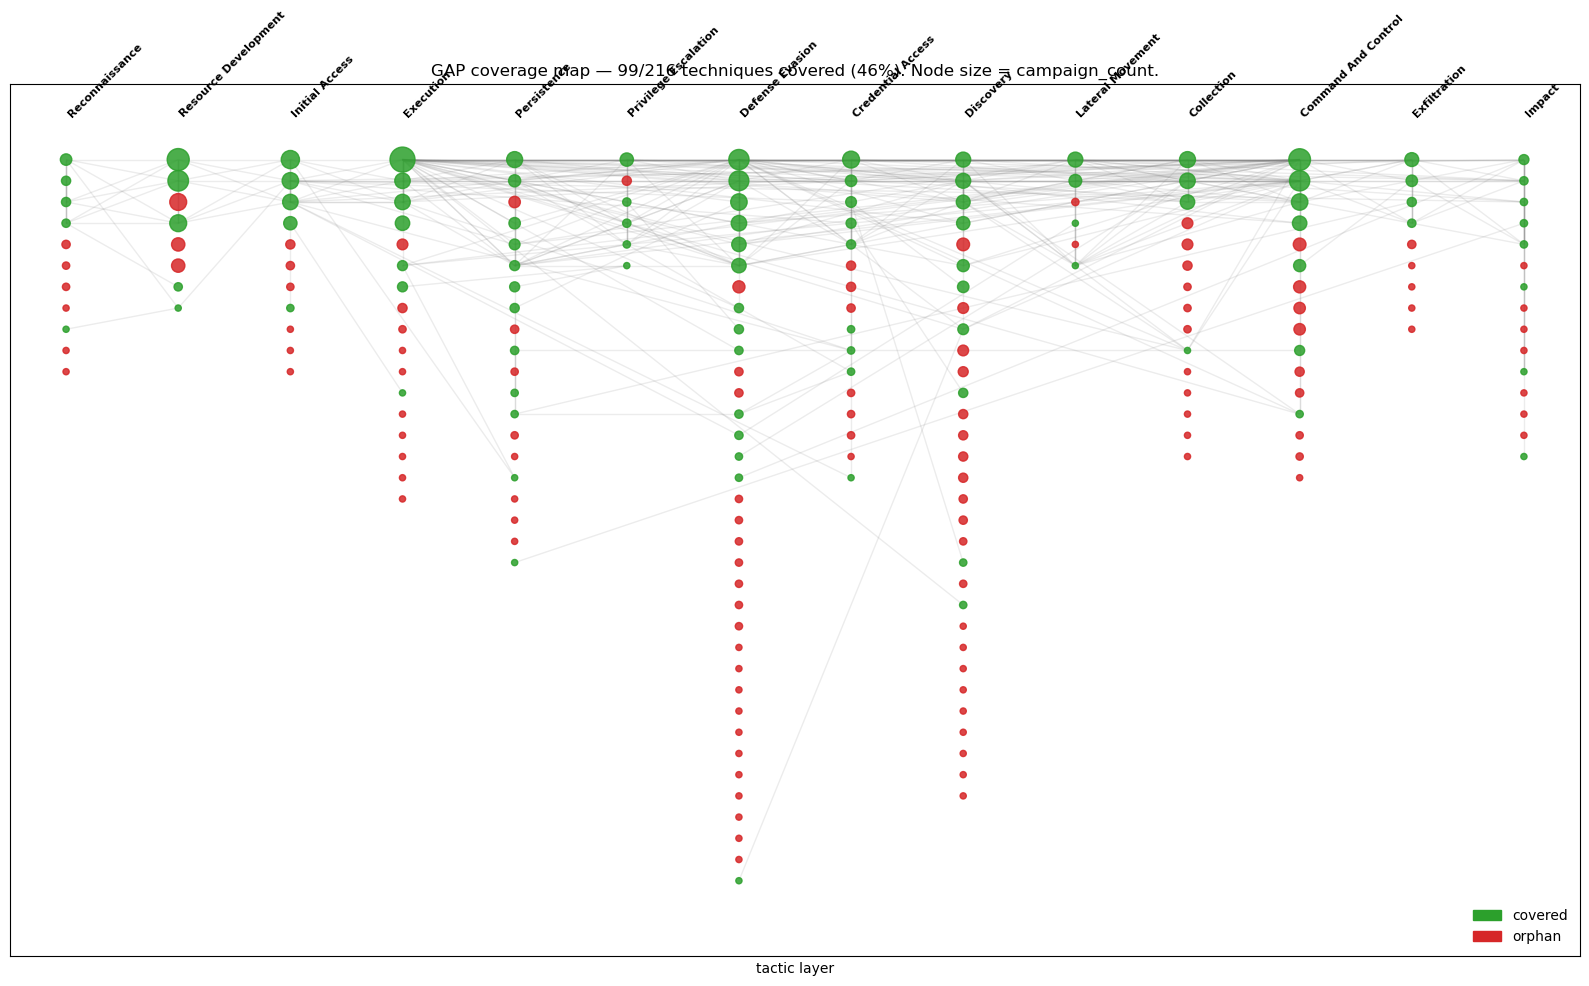

In [32]:
# Visualise: GAP layered layout, covered nodes green, orphans red, sized by campaign_count.
fig, ax = plt.subplots(figsize=(16, 10))

# Position: x = tactic layer, y = ordering within layer
positions = {}
layer_buckets = defaultdict(list)
for _, row in gap_nodes.iterrows():
    layer_buckets[row["tactic_layer"]].append(row["technique_id"])
for layer, tids in layer_buckets.items():
    tids_sorted = sorted(tids,
                         key=lambda t: -gap_nodes.set_index("technique_id").loc[t, "campaign_count"])
    for i, tid in enumerate(tids_sorted):
        positions[tid] = (layer, -i)

G_gap = nx.DiGraph()
for tid in gap_nodes.technique_id:
    G_gap.add_node(tid)
for (s, d) in unified:
    if s in positions and d in positions:
        G_gap.add_edge(s, d)

camp_counts = gap_nodes.set_index("technique_id")["campaign_count"].to_dict()
node_colors = ["#2ca02c" if t in covered_any else "#d62728" for t in G_gap.nodes]
node_sizes = [20 + 8 * camp_counts.get(t, 0) for t in G_gap.nodes]

nx.draw_networkx_edges(G_gap, positions, edge_color="grey", alpha=0.15,
                       arrows=False, ax=ax)
nx.draw_networkx_nodes(G_gap, positions, node_color=node_colors,
                       node_size=node_sizes, alpha=0.85, ax=ax)

for layer, tids in layer_buckets.items():
    ax.text(layer, 2, TACTIC_DISPLAY[CANONICAL_TACTICS[layer]],
            rotation=45, ha="left", fontsize=8, fontweight="bold")

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2ca02c", label="covered"),
                   Patch(color="#d62728", label="orphan")],
          loc="lower right", frameon=False)
ax.set_title(f"GAP coverage map — {sum(1 for t in G_gap.nodes if t in covered_any)}/{len(G_gap.nodes)} techniques covered "
             f"({any_pct:.0f}%). Node size = campaign_count.")
ax.set_xlabel("tactic layer")
ax.set_xticks(range(len(CANONICAL_TACTICS)))
ax.set_yticks([])
ax.set_xlim(-0.5, len(CANONICAL_TACTICS) - 0.5)
plt.tight_layout()
plt.show()


In [33]:
# Top 20 orphan techniques by campaign_count — the manual annotation priority list.
orphans = gap_nodes[~gap_nodes.technique_id.isin(covered_any)].copy()
orphans = orphans.sort_values("campaign_count", ascending=False)

print(f"Total orphan techniques: {len(orphans)}\n")
print("Top 20 orphans to annotate first (sorted by campaign_count):\n")
print(f"{'#':>3}  {'tid':<8}  {'cnt':>4}  {'tactic':<22}  name")
print("-" * 90)
for i, (_, row) in enumerate(orphans.head(20).iterrows(), 1):
    print(f"{i:>3}  {row['technique_id']:<8}  {row['campaign_count']:>4}  "
          f"{TACTIC_DISPLAY[row['primary_tactic']]:<22}  {row['name']}")


Total orphan techniques: 117

Top 20 orphans to annotate first (sorted by campaign_count):

  #  tid        cnt  tactic                  name
------------------------------------------------------------------------------------------
  1  T1584       16  Resource Development    Compromise Infrastructure
  2  T1608        9  Resource Development    Stage Capabilities
  3  T1585        9  Resource Development    Establish Accounts
  4  T1095        8  Command And Control     Non-Application Layer Protocol
  5  T1018        8  Discovery               Remote System Discovery
  6  T1571        7  Command And Control     Non-Standard Port
  7  T1553        7  Defense Evasion         Subvert Trust Controls
  8  T1546        6  Persistence             Event Triggered Execution
  9  T1572        6  Command And Control     Protocol Tunneling
 10  T1568        6  Command And Control     Dynamic Resolution
 11  T1213        5  Collection              Data from Information Repositories
 12  T1069   

**Key output for the GAP.** This is the bridge from the comparative analysis to the actual GAP construction work. The orphan list above is the **input to Phase 2c** of the GAP construction algorithm: every technique on it needs at least one incoming edge before the GAP is complete. Sorted by `campaign_count`, it tells me exactly which manual annotations have the highest impact on the final graph.

## Summary

| Section | Source | Edges produced | Notes |
|---------|--------|----------------|-------|
| §2 | Rahman co-occurrence | many | empirical, no causation; needs cross-tactic filter |
| §3 | Choi HMM (composed) | many | best as ordering validation; weaker as direct edge source |
| §4 | DeepOP-style ontology | few | high-evidence, documentation-cited |
| §5 | Attack Flow corpus | gold | manually curated; subject to corpus availability |
| §6 | Unified | (union) | consensus edges = highest confidence |
| §7 | Coverage vs GAP nodes | — | orphan list = manual annotation priorities |

Next concrete step for the GAP: lift the consensus edges from §6 directly into the GAP edge set (each gets `evidence` records citing the contributing sources), then work down the §7 orphan list.
